In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from UPVfab_tools import open_file, filter_wavelength, find_minima, smooth_signal

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Functions

In [2]:
def plot_spectra_smooth(wavelength_dut, power_dut, power_dut_smooth, power_wg, power_wg_smooth, threshold, threshold_smooth, separation, dut_name):
    #####################################################################################################################
    # Function to plot the spectra of the DUT and difference with reference waveguide smoothed, including minima points    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_dut_smooth: array of smoothed power values for the DUT
    # - power_wg: array of reference waveguide power values
    # - power_wg_smooth: array of smoothed reference waveguide power values
    # - threshold: minimum power difference threshold for finding minima in the original spectrum
    # - threshold_smooth: minimum power difference threshold for finding minima in the smoothed spectrum
    # - separation: minimum separation between minima (in nm)
    # - dut_name: name of the DUT for labeling the plots
    # Outputs:
    # - wl_min: array of wavelength values corresponding to the found minima
    #####################################################################################################################

    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    if max(power_diff) > 0:
        power_diff = power_diff - np.max(power_diff)
    
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)

    wl_min = wavelength_dut[indices]
    power_min = power_dut[indices]
    power_diff_min = power_diff[indices]

    # Power difference with reference waveguides (Smoothed)
    power_diff_smooth = power_dut_smooth - power_wg_smooth
    if max(power_diff_smooth) > 0:
        power_diff_smooth = power_diff_smooth - np.max(power_diff_smooth)

    indices_smooth = find_minima(power_diff_smooth, wavelength_dut, threshold_smooth, separation)

    wl_min_smooth = wavelength_dut[indices_smooth]
    power_min_smooth = power_dut_smooth[indices_smooth]
    power_diff_min_smooth = power_diff_smooth[indices_smooth]

    plt.figure(figsize=(8, 4))
    plt.plot(wavelength_dut, power_dut, color='blue', alpha=0.5, label='DUT')
    plt.plot(wavelength_dut, power_dut_smooth, color='blue', label='DUT (Smooth)', linestyle='--')

    plt.plot(wavelength_dut, power_wg, color='gray', alpha=0.5, label='Reference Waveguide')
    plt.plot(wavelength_dut, power_wg_smooth, color='gray', linestyle='--', label='Reference Waveguide (Smooth)')
    plt.scatter(wl_min, power_min, color='red', alpha=0.5, label='Minima')
    plt.scatter(wl_min_smooth, power_min_smooth, color='red', label='Minima (Smooth)')

    # Plot measured spectrum
    for i in range(len(wl_min)):
        plt.annotate(i, (wl_min[i], power_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red', alpha=0.5)
    for i in range(len(wl_min_smooth)):
        plt.annotate(i, (wl_min_smooth[i], power_min_smooth[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    plt.title(f"{dut_name}: Optical Spectrum")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power (dBm)")
    plt.legend(fontsize=9, bbox_to_anchor=(1, 1), loc='upper left')
    plt.grid()
    plt.show()

    # Plot difference with reference waveguide
    plt.figure(figsize=(8, 4))
    plt.plot(wavelength_dut, power_diff, color='blue', alpha=0.5, label='DUT')
    plt.plot(wavelength_dut, power_diff_smooth, color='blue', linestyle='--', label='DUT (Smooth)')
    plt.scatter(wl_min, power_diff_min, color='red', alpha=0.5, label='Minima')
    plt.scatter(wl_min_smooth, power_diff_min_smooth, color='red', label='Minima (Smooth)')

    for i in range(len(wl_min)):
        plt.annotate(i, (wl_min[i], power_diff_min[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red', alpha=0.5)
        
    for i in range(len(wl_min_smooth)):
        plt.annotate(i, (wl_min_smooth[i], power_diff_min_smooth[i]), textcoords="offset points", xytext=(0,-20), ha='center', color='red')

    plt.title(f"{dut_name}: Optical Spectrum Difference")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power (dBm)")
    plt.legend(fontsize=9, bbox_to_anchor=(1, 1), loc='upper left')
    plt.grid()
    plt.show()

    print(f"Minimums found in {dut_name} at wavelengths: {wl_min} nm")

    return wl_min, wl_min_smooth, power_diff_min, power_diff_min_smooth

def reflectivity(wavelength_dut, power_dut, power_wg, threshold, separation, window_size):
    #####################################################################################################################
    # Function to calculate the reflectivity of the DUT from the power difference with reference waveguide
    # Inputs:
    # - wavelength_dut: array of wavelength values
    # - power_dut: array of power values
    # - power_wg: array of reference waveguide power values
    # - threshold: minimum power difference threshold
    # - separation: minimum separation between minima
    # - window_size: size of the window around each minimum
    # Outputs:
    # - R: array of reflectivity values
    #####################################################################################################################
    
    # Power difference with reference waveguides
    power_diff = power_dut - power_wg
    power_diff = power_diff - np.max(power_diff)

    # Find minimums
    indices = find_minima(power_diff, wavelength_dut, threshold, separation)
    wl_min = wavelength_dut[indices]
    power_diff_min = power_diff[indices]

    T = np.zeros(len(wl_min))
    BW = np.zeros(len(wl_min))

    for idx in range(len(wl_min)):
        # Window around each minimum
        wl_0 = wl_min[idx] - window_size/2
        wl_1 = wl_min[idx] + window_size/2

        wavelength_zoom, power_zoom = filter_wavelength(wavelength_dut, power_diff, wl_0, wl_1)
        
        # Calculate transmittivity
        T[idx] = 10**((power_diff_min[idx]-max(power_zoom))/10)

        # Bandwidth
        indices_bw = find_minima(-power_zoom, wavelength_zoom, 0.0, 0.1)

        idx_left = indices_bw[0]
        idx_right = indices_bw[-1]
  
        BW[idx] = wavelength_zoom[idx_right] - wavelength_zoom[idx_left]
    R = 1 - T
    return R, BW

def grating_strength(original_wl, measured_wl, R, dW, N, n_eff):
    ###########################################################################################################################
    # Function to calculate the grating strength (kappa) and length (L) of the grating from the reflectivity and the shift in wavelength
    # Inputs:
    # - original_wl: array of original wavelength values corresponding to the design
    # - measured_wl: array of measured wavelength values corresponding to the found minima
    # - R: array of reflectivity values corresponding to each minimum
    # - dW: array of design wavelength shifts corresponding to each minimum
    # - N: number of periods of the grating
    # - n_eff: effective index of the waveguide
    # Outputs:
    # - kappa: array of grating strength values corresponding to each minimum
    # - L: array of grating length values corresponding to each minimum
    # - dW: array of wavelength shifts corresponding to each minimum (same as input)
    ###########################################################################################################################
   
    n = len(original_wl)-len(measured_wl)
    dW = dW[n:]

    period = original_wl/(2*n_eff)*1e-9
    L = N*period[n:]
    kappa = np.arctanh(np.sqrt(R))/L

    return kappa, L, dW

def shift_analysis(original_wl, measured_wl, n_eff):
    ###########################################################################################################################
    # Function to calculate the shifted resonance respect to design, and the corresponding shift in effective index
    # Inputs:
    # - original_wl: array of original wavelength values corresponding to the design
    # - measured_wl: array of measured wavelength values corresponding to the found minima
    # - n_eff: effective index of the waveguide
    # Outputs:
    # - lambda_shift: array of wavelength shifts corresponding to each minimum
    # - n_shift: array of effective index shifts corresponding to each minimum
    ###########################################################################################################################

    n = len(original_wl)-len(measured_wl)

    lambda_shift = original_wl[n:] - measured_wl
    period = original_wl/(2*n_eff)*1e-9
    n_shift = (original_wl[n:]-measured_wl)/(2*period[n:])*1e-9
    
    return lambda_shift, n_shift

def group_index(bragg_wl, bandwidth, kappa, length): 
    ###############################################################################################################################
    # Function to calculate the group index of the grating from the bandwidth, grating strength and length
    # Inputs:
    # - bragg_wl: array of Bragg wavelength values corresponding to each minimum
    # - bandwidth: array of bandwidth values corresponding to each minimum
    # - kappa: array of grating strength values corresponding to each minimum
    # - length: array of grating length values corresponding to each minimum
    # Outputs:
    # - ng: array of group index values corresponding to each minimum
    ###############################################################################################################################

    ng = (bragg_wl)**2/(np.pi*bandwidth)*np.sqrt(kappa**2 + (np.pi/length)**2)*1e-9
    
    return ng

def reflectivity_model(x, k):
    return np.tanh(k*x)**2

# Initialization

In [3]:
# Laser range
d_wl = 4
wl_0 = 1530 - d_wl 
wl_1 = 1600 + d_wl

n_eff = 1.5743

# U1 design parameters
N_u1 = 1000
wl_u1 = (np.arange(8)-3)*10 + 1550
dW_u1 = (np.arange(8)+1)*50

period_u1 = wl_u1/(2*n_eff)*1e-9
L_u1 = N_u1*period_u1

# U2 design parameters
N_u2 = 2000
wl_u2 = (np.arange(6)-2)*10 + 1550
dW_u2 = (np.arange(6)+1)*50

period_u2 = wl_u2/(2*n_eff)*1e-9
L_u2 = N_u2*period_u2

# U3 design parameters
N_u3 = 4000
wl_u3 = (np.arange(4)-2)*10 + 1550
dW_u3 = (np.arange(4)+2)*50

period_u3 = wl_u3/(2*n_eff)*1e-9
L_u3 = N_u3*period_u3

In [4]:
##### Reference Waveguides ##############################################################################
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\wg.txt" 
wavelength_wg_r2, power_wg_r2 = open_file(file_path)
wavelength_wg_r2, power_wg_r2 = filter_wavelength(wavelength_wg_r2, power_wg_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\wg.txt" 
wavelength_wg_r4, power_wg_r4 = open_file(file_path)
wavelength_wg_r4, power_wg_r4 = filter_wavelength(wavelength_wg_r4, power_wg_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\wg.txt" 
wavelength_wg_r7, power_wg_r7 = open_file(file_path)
wavelength_wg_r7, power_wg_r7 = filter_wavelength(wavelength_wg_r7, power_wg_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\wg.txt" 
wavelength_wg_r10, power_wg_r10 = open_file(file_path)
wavelength_wg_r10, power_wg_r10 = filter_wavelength(wavelength_wg_r10, power_wg_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\wg.txt" 
wavelength_wg_r12, power_wg_r12 = open_file(file_path)
wavelength_wg_r12, power_wg_r12 = filter_wavelength(wavelength_wg_r12, power_wg_r12, wl_0, wl_1)

##### U1 ################################################################################################
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u1.txt" 
wavelength_u1_r2, power_u1_r2 = open_file(file_path)
wavelength_u1_r2, power_u1_r2 = filter_wavelength(wavelength_u1_r2, power_u1_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u1.txt" 
wavelength_u1_r4, power_u1_r4 = open_file(file_path)
wavelength_u1_r4, power_u1_r4 = filter_wavelength(wavelength_u1_r4, power_u1_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u1.txt" 
wavelength_u1_r7, power_u1_r7 = open_file(file_path)
wavelength_u1_r7, power_u1_r7 = filter_wavelength(wavelength_u1_r7, power_u1_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u1.txt" 
wavelength_u1_r10, power_u1_r10 = open_file(file_path)
wavelength_u1_r10, power_u1_r10 = filter_wavelength(wavelength_u1_r10, power_u1_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u1.txt" # Read mode so \u... is not interpreted as unicode
wavelength_u1_r12, power_u1_r12 = open_file(file_path)
wavelength_u1_r12, power_u1_r12 = filter_wavelength(wavelength_u1_r12, power_u1_r12, wl_0, wl_1)

##### U2 ################################################################################################
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u2.txt" 
wavelength_u2_r2, power_u2_r2 = open_file(file_path)
wavelength_u2_r2, power_u2_r2 = filter_wavelength(wavelength_u2_r2, power_u2_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u2.txt" 
wavelength_u2_r4, power_u2_r4 = open_file(file_path)
wavelength_u2_r4, power_u2_r4 = filter_wavelength(wavelength_u2_r4, power_u2_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u2.txt" 
wavelength_u2_r7, power_u2_r7 = open_file(file_path)
wavelength_u2_r7, power_u2_r7 = filter_wavelength(wavelength_u2_r7, power_u2_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u2.txt" 
wavelength_u2_r10, power_u2_r10 = open_file(file_path)
wavelength_u2_r10, power_u2_r10 = filter_wavelength(wavelength_u2_r10, power_u2_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u2.txt" 
wavelength_u2_r12, power_u2_r12 = open_file(file_path)
wavelength_u2_r12, power_u2_r12 = filter_wavelength(wavelength_u2_r12, power_u2_r12, wl_0, wl_1)

##### U3 ################################################################################################
file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/2/5\u3.txt" 
wavelength_u3_r2, power_u3_r2 = open_file(file_path)
wavelength_u3_r2, power_u3_r2 = filter_wavelength(wavelength_u3_r2, power_u3_r2, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/4/5\u3.txt" 
wavelength_u3_r4, power_u3_r4 = open_file(file_path)
wavelength_u3_r4, power_u3_r4 = filter_wavelength(wavelength_u3_r4, power_u3_r4, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/7/5\u3.txt" 
wavelength_u3_r7, power_u3_r7 = open_file(file_path)
wavelength_u3_r7, power_u3_r7 = filter_wavelength(wavelength_u3_r7, power_u3_r7, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/10/5\u3.txt" 
wavelength_u3_r10, power_u3_r10 = open_file(file_path)
wavelength_u3_r10, power_u3_r10 = filter_wavelength(wavelength_u3_r10, power_u3_r10, wl_0, wl_1)

file_path = r"/home/arjoa/UPVfab/test_osa/data/PHYSIS/17753-4 v3/12/5\u3.txt" 
wavelength_u3_r12, power_u3_r12 = open_file(file_path)
wavelength_u3_r12, power_u3_r12 = filter_wavelength(wavelength_u3_r12, power_u3_r12, wl_0, wl_1)

# Routine

## Reference Waveguides

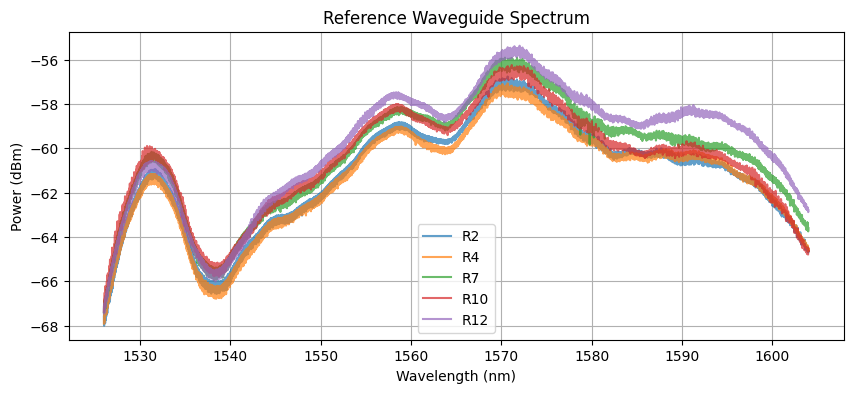

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(wavelength_wg_r2, power_wg_r2, label='R2', alpha = 0.7)
plt.plot(wavelength_wg_r4, power_wg_r4, label='R4', alpha = 0.7)
plt.plot(wavelength_wg_r7, power_wg_r7, label='R7', alpha = 0.7)
plt.plot(wavelength_wg_r10, power_wg_r10, label='R10', alpha = 0.7)
plt.plot(wavelength_wg_r12, power_wg_r12, label='R12', alpha = 0.7)

plt.title("Reference Waveguide Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (dBm)")
plt.grid()
plt.legend() 
plt.show()

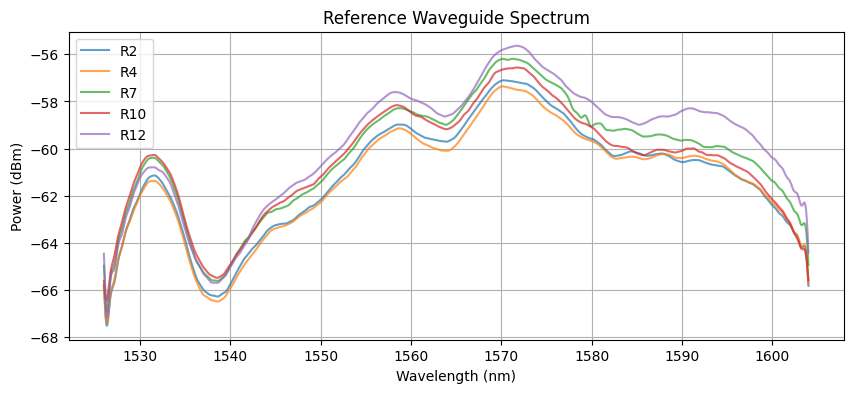

In [6]:
tc = 0.01         # Cutoff time for Fourier filtering (s)

power_wg_r2_s = smooth_signal(wavelength_wg_r2, power_wg_r2, tc=tc, plot=False)
power_wg_r4_s = smooth_signal(wavelength_wg_r4, power_wg_r4, tc=tc, plot=False)
power_wg_r7_s = smooth_signal(wavelength_wg_r7, power_wg_r7, tc=tc, plot=False)
power_wg_r10_s = smooth_signal(wavelength_wg_r10, power_wg_r10, tc=tc, plot=False)
power_wg_r12_s = smooth_signal(wavelength_wg_r12, power_wg_r12, tc=tc, plot=False)

plt.figure(figsize=(10, 4))
plt.plot(wavelength_wg_r2, power_wg_r2_s, label='R2', alpha = 0.7)
plt.plot(wavelength_wg_r4, power_wg_r4_s, label='R4', alpha = 0.7)
plt.plot(wavelength_wg_r7, power_wg_r7_s, label='R7', alpha = 0.7)
plt.plot(wavelength_wg_r10, power_wg_r10_s, label='R10', alpha = 0.7)
plt.plot(wavelength_wg_r12, power_wg_r12_s, label='R12', alpha = 0.7)

plt.title("Reference Waveguide Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (dBm)")
plt.grid()
plt.legend() 
plt.show()

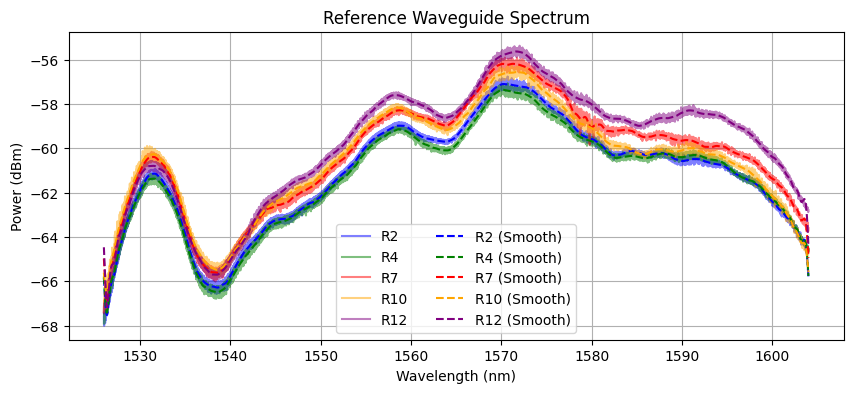

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(wavelength_wg_r2, power_wg_r2, label='R2', alpha = 0.5, color = 'blue')
plt.plot(wavelength_wg_r4, power_wg_r4, label='R4', alpha = 0.5, color = 'green')
plt.plot(wavelength_wg_r7, power_wg_r7, label='R7', alpha = 0.5, color = 'red')
plt.plot(wavelength_wg_r10, power_wg_r10, label='R10', alpha = 0.5, color = 'orange')
plt.plot(wavelength_wg_r12, power_wg_r12, label='R12', alpha = 0.5, color = 'purple')

plt.plot(wavelength_wg_r2, power_wg_r2_s, label='R2 (Smooth)', linestyle ='--', color = 'blue')
plt.plot(wavelength_wg_r4, power_wg_r4_s, label='R4 (Smooth)', linestyle ='--', color = 'green')
plt.plot(wavelength_wg_r7, power_wg_r7_s, label='R7 (Smooth)', linestyle ='--', color = 'red')
plt.plot(wavelength_wg_r10, power_wg_r10_s, label='R10 (Smooth)', linestyle ='--', color = 'orange')
plt.plot(wavelength_wg_r12, power_wg_r12_s, label='R12 (Smooth)', linestyle ='--', color = 'purple')

plt.title("Reference Waveguide Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Power (dBm)")
plt.grid()
plt.legend(ncol=2) 
plt.show()

## U1

### Optical Spectrum

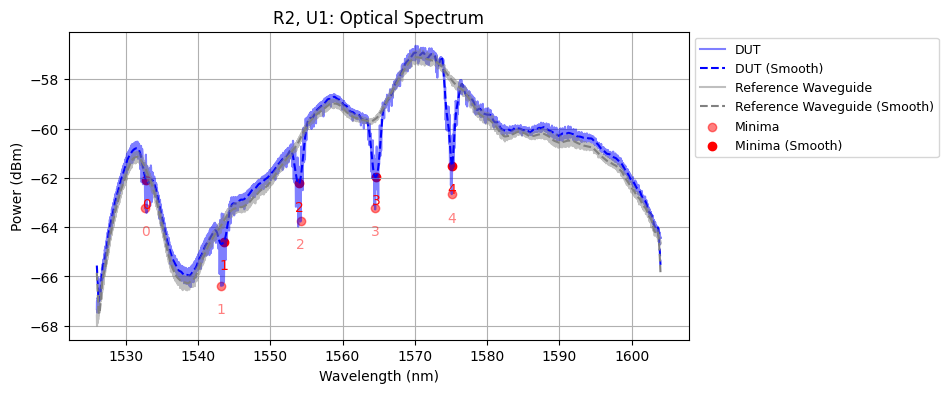

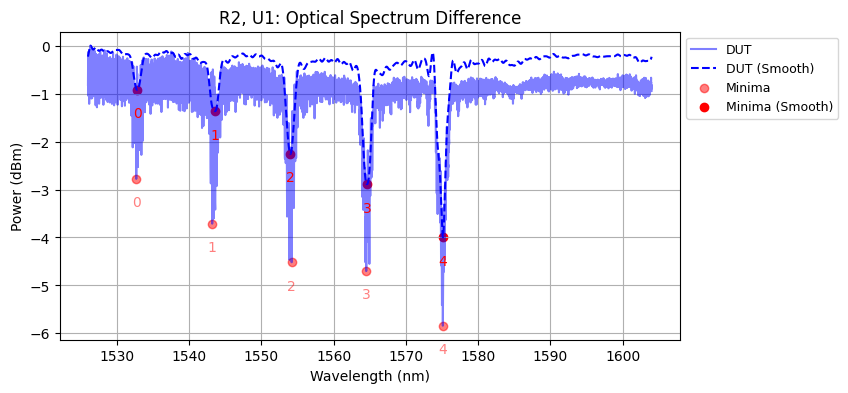

Minimums found in R2, U1 at wavelengths: [1532.684 1543.192 1554.184 1564.508 1575.108] nm


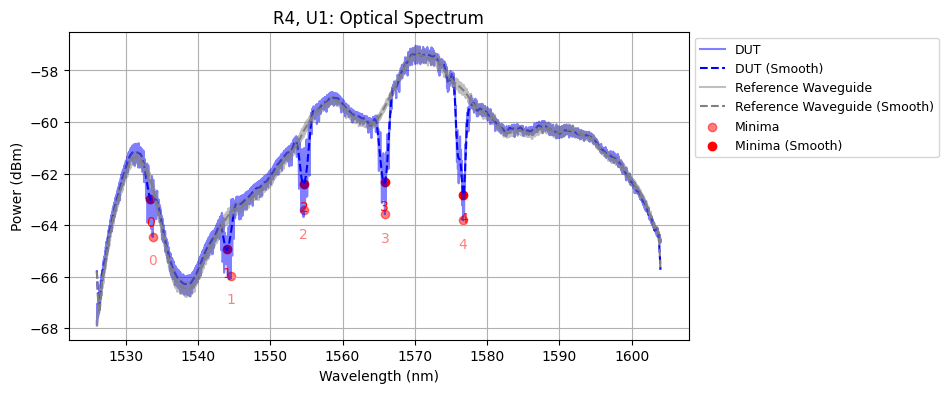

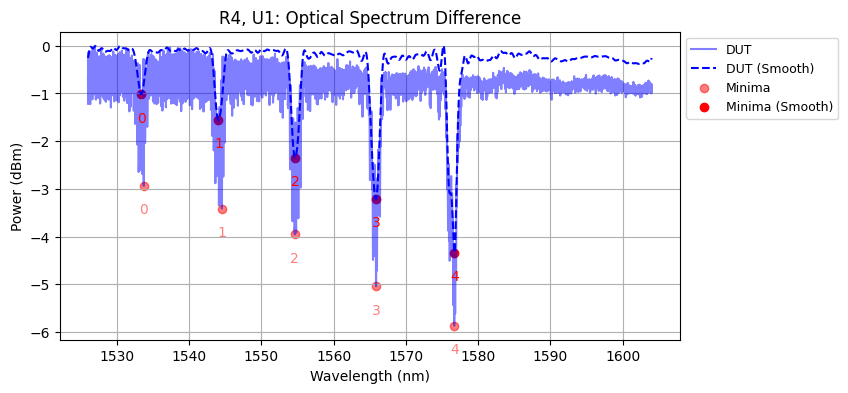

Minimums found in R4, U1 at wavelengths: [1533.72  1544.536 1554.62  1565.864 1576.684] nm


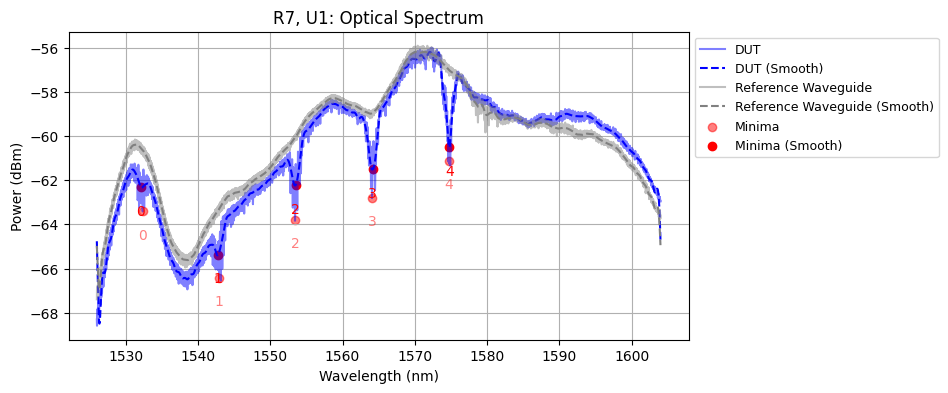

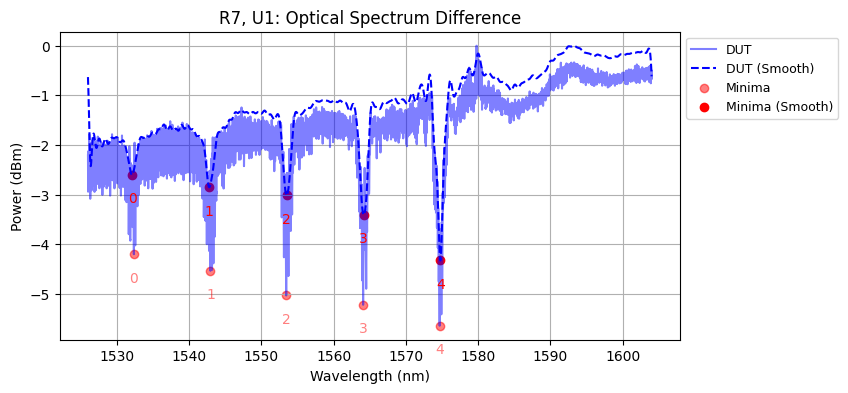

Minimums found in R7, U1 at wavelengths: [1532.352 1542.948 1553.432 1564.076 1574.664] nm


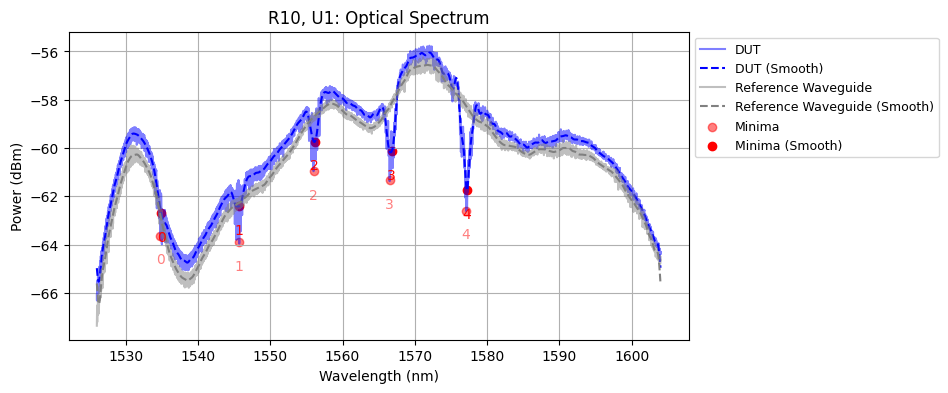

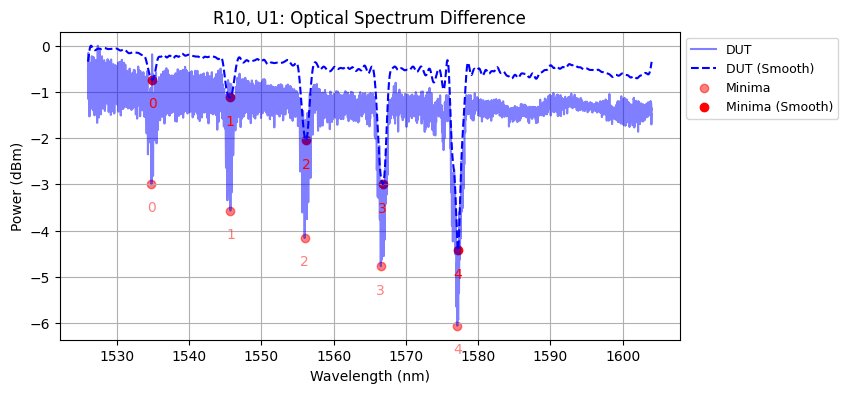

Minimums found in R10, U1 at wavelengths: [1534.784 1545.712 1555.984 1566.52  1577.108] nm


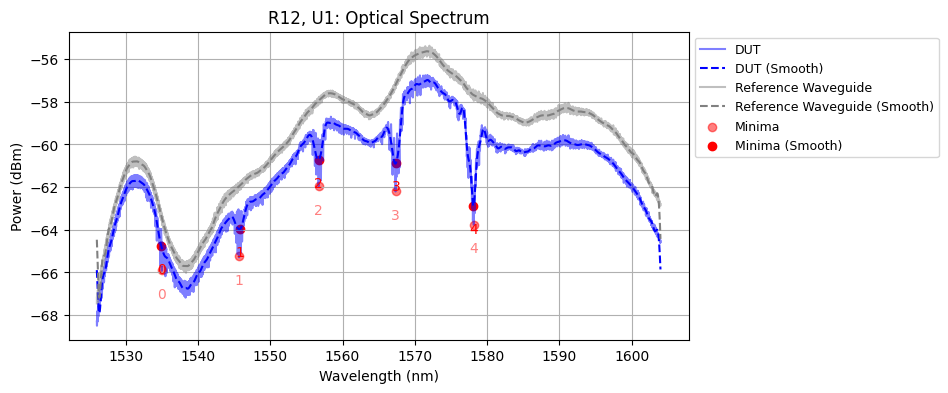

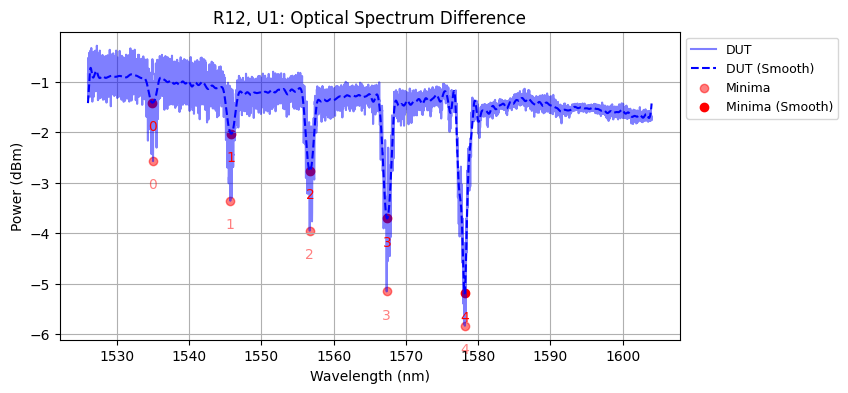

Minimums found in R12, U1 at wavelengths: [1535.    1545.7   1556.684 1567.332 1578.16 ] nm


In [8]:
# Processing parameters
tc = 0.01         # Cutoff time for Fourier filtering (s)
threshold = 1.5     # For minima detection (dB)
threshold_s = 0.4   
separation = 10      # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

# Smooth spectra
power_u1_r2_s = smooth_signal(wavelength_u1_r2, power_u1_r2, tc=tc, plot=False)
power_u1_r4_s = smooth_signal(wavelength_u1_r4, power_u1_r4, tc=tc, plot=False)
power_u1_r7_s = smooth_signal(wavelength_u1_r7, power_u1_r7, tc=tc, plot=False)
power_u1_r10_s = smooth_signal(wavelength_u1_r10, power_u1_r10, tc=tc, plot=False)
power_u1_r12_s = smooth_signal(wavelength_u1_r12, power_u1_r12, tc=tc, plot=False)

# Plot spectra and minima
wl_u1_r2, wl_u1_r2_s, power_u1_r2_min, power_u1_r2_min_s = plot_spectra_smooth(wavelength_u1_r2, power_u1_r2, power_u1_r2_s, power_wg_r2, power_wg_r2_s, threshold, threshold_s, separation, "R2, U1")
wl_u1_r4, wl_u1_r4_s, power_u1_r4_min, power_u1_r4_min_s = plot_spectra_smooth(wavelength_u1_r4, power_u1_r4, power_u1_r4_s, power_wg_r4, power_wg_r4_s, threshold, threshold_s, separation, "R4, U1")
wl_u1_r7, wl_u1_r7_s, power_u1_r7_min, power_u1_r7_min_s = plot_spectra_smooth(wavelength_u1_r7, power_u1_r7, power_u1_r7_s, power_wg_r7, power_wg_r7_s, threshold, threshold_s, separation, "R7, U1")
wl_u1_r10, wl_u1_r10_s, power_u1_r10_min, power_u1_r10_min_s = plot_spectra_smooth(wavelength_u1_r10, power_u1_r10, power_u1_r10_s, power_wg_r10, power_wg_r10_s, threshold, threshold_s, separation, "R10, U1")
wl_u1_r12, wl_u1_r12_s, power_u1_r12_min, power_u1_r12_min_s = plot_spectra_smooth(wavelength_u1_r12, power_u1_r12, power_u1_r12_s, power_wg_r12, power_wg_r12_s, threshold, threshold_s, separation, "R12, U1")

### Reflectivity & Grating Strength

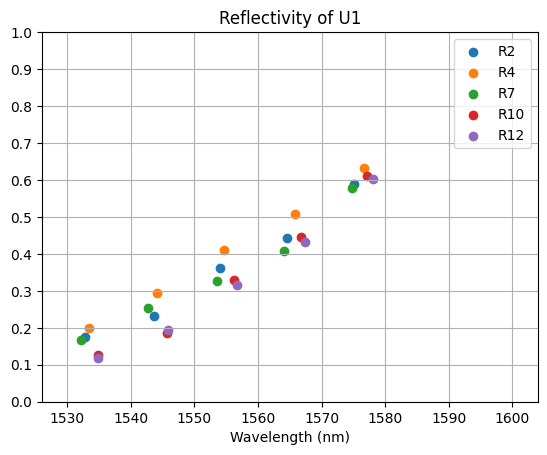

In [9]:
R_u1_r2_s, BW_u1_r2_s = reflectivity(wavelength_u1_r2, power_u1_r2_s, power_wg_r2_s, threshold_s, separation, window_size)
R_u1_r4_s, BW_u1_r4_s = reflectivity(wavelength_u1_r4, power_u1_r4_s, power_wg_r4_s, threshold_s, separation, window_size)
R_u1_r7_s, BW_u1_r7_s = reflectivity(wavelength_u1_r7, power_u1_r7_s, power_wg_r7_s, threshold_s, separation, window_size)
R_u1_r10_s, BW_u1_r10_s = reflectivity(wavelength_u1_r10, power_u1_r10_s, power_wg_r10_s, threshold_s, separation, window_size)
R_u1_r12_s, BW_u1_r12_s = reflectivity(wavelength_u1_r12, power_u1_r12_s, power_wg_r12_s, threshold_s, separation, window_size)

plt.scatter(wl_u1_r2_s, R_u1_r2_s, label='R2')
plt.scatter(wl_u1_r4_s, R_u1_r4_s, label='R4')
plt.scatter(wl_u1_r7_s, R_u1_r7_s, label='R7')
plt.scatter(wl_u1_r10_s, R_u1_r10_s, label='R10')
plt.scatter(wl_u1_r12_s, R_u1_r12_s, label='R12')

plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U1")
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

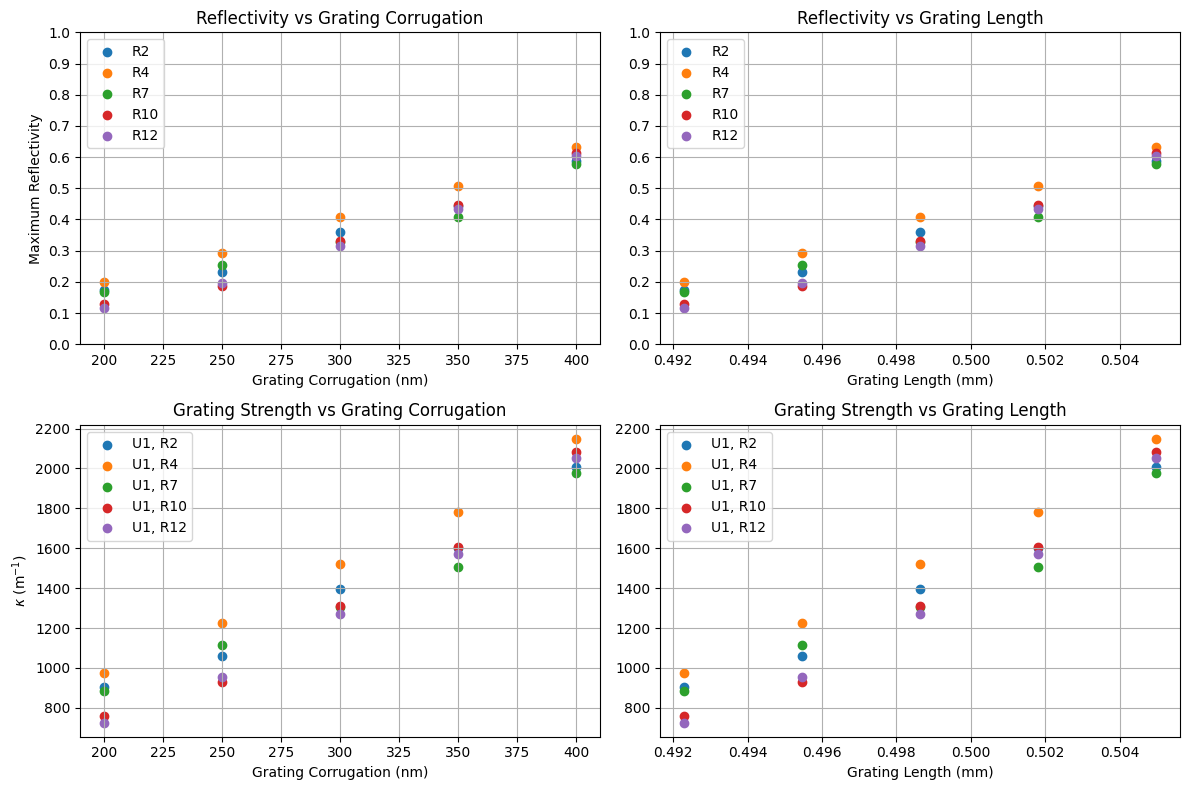

In [10]:
k_u1_r2_s, L_u1_r2_s, dW_u1_r2_s = grating_strength(wl_u1, wl_u1_r2_s, R_u1_r2_s, dW_u1, N_u1, n_eff)
k_u1_r4_s, L_u1_r4_s, dW_u1_r4_s = grating_strength(wl_u1, wl_u1_r4_s, R_u1_r4_s, dW_u1, N_u1, n_eff)
k_u1_r7_s, L_u1_r7_s, dW_u1_r7_s = grating_strength(wl_u1, wl_u1_r7_s, R_u1_r7_s, dW_u1, N_u1, n_eff)
k_u1_r10_s, L_u1_r10_s, dW_u1_r10_s = grating_strength(wl_u1, wl_u1_r10_s, R_u1_r10_s, dW_u1, N_u1, n_eff)
k_u1_r12_s, L_u1_r12_s, dW_u1_r12_s = grating_strength(wl_u1, wl_u1_r12_s, R_u1_r12_s, dW_u1, N_u1, n_eff)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].scatter(dW_u1_r2_s, R_u1_r2_s, label = 'R2')
axs[0, 0].scatter(dW_u1_r4_s, R_u1_r4_s, label = 'R4')
axs[0, 0].scatter(dW_u1_r7_s, R_u1_r7_s, label = 'R7')
axs[0, 0].scatter(dW_u1_r10_s, R_u1_r10_s, label = 'R10')
axs[0, 0].scatter(dW_u1_r12_s, R_u1_r12_s, label = 'R12')

axs[0, 0].set_xlabel("Grating Corrugation (nm)")
axs[0, 0].set_ylabel("Maximum Reflectivity")
axs[0, 0].set_title("Reflectivity vs Grating Corrugation")
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 0].grid()
axs[0, 0].legend()   

axs[0, 1].scatter(L_u1_r2_s*1e3, R_u1_r2_s, label = 'R2')
axs[0, 1].scatter(L_u1_r4_s*1e3, R_u1_r4_s, label = 'R4')
axs[0, 1].scatter(L_u1_r7_s*1e3, R_u1_r7_s, label = 'R7')
axs[0, 1].scatter(L_u1_r10_s*1e3, R_u1_r10_s, label = 'R10')
axs[0, 1].scatter(L_u1_r12_s*1e3, R_u1_r12_s, label = 'R12')
axs[0, 1].set_title("Reflectivity vs Grating Length")

axs[0, 1].set_xlabel("Grating Length (mm)")
axs[0, 1].set_ylim(0, 1)
axs[0, 1].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 1].grid()
axs[0, 1].legend() 


axs[1, 0].scatter(dW_u1_r2_s, k_u1_r2_s, label = 'U1, R2')
axs[1, 0].scatter(dW_u1_r4_s, k_u1_r4_s, label = 'U1, R4')
axs[1, 0].scatter(dW_u1_r7_s, k_u1_r7_s, label = 'U1, R7')
axs[1, 0].scatter(dW_u1_r10_s, k_u1_r10_s, label = 'U1, R10')
axs[1, 0].scatter(dW_u1_r12_s, k_u1_r12_s, label = 'U1, R12')
axs[1, 0].set_xlabel("Grating Corrugation (nm)")
axs[1, 0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[1, 0].set_title(r"Grating Strength vs Grating Corrugation")
axs[1, 0].grid()
axs[1, 0].legend()   

axs[1, 1].scatter(L_u1_r2_s*1e3, k_u1_r2_s, label = 'U1, R2')
axs[1, 1].scatter(L_u1_r4_s*1e3, k_u1_r4_s, label = 'U1, R4')
axs[1, 1].scatter(L_u1_r7_s*1e3, k_u1_r7_s, label = 'U1, R7')
axs[1, 1].scatter(L_u1_r10_s*1e3, k_u1_r10_s, label = 'U1, R10')
axs[1, 1].scatter(L_u1_r12_s*1e3, k_u1_r12_s, label = 'U1, R12')
axs[1, 1].set_xlabel("Grating Length (mm)")
axs[1, 1].set_title(r"Grating Strength vs Grating Length")
axs[1, 1].grid()
axs[1, 1].legend()   

plt.tight_layout()
plt.show()

### Refractive Index

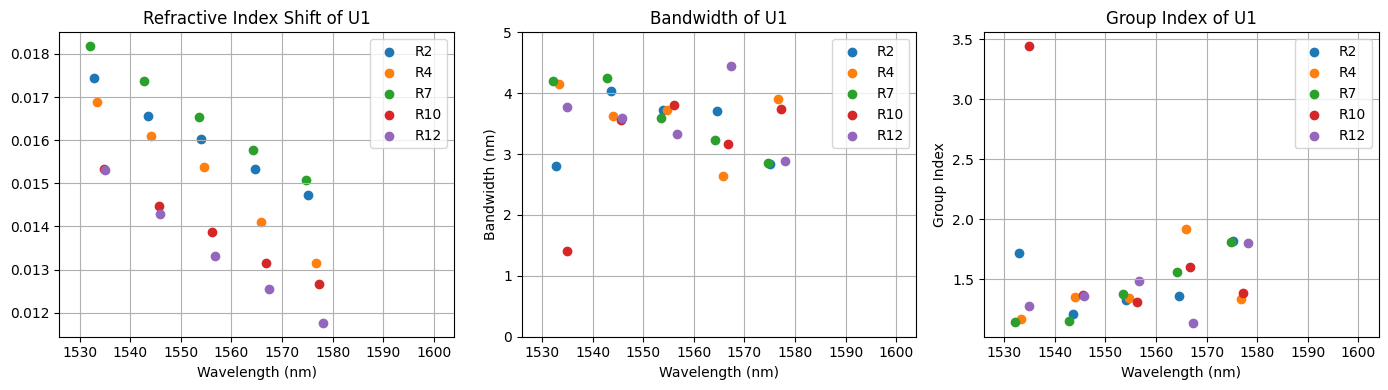

In [11]:
dwl_u1_r2_s, dn_u1_r2_s = shift_analysis(wl_u1, wl_u1_r2_s, n_eff)
dwl_u1_r4_s, dn_u1_r4_s = shift_analysis(wl_u1, wl_u1_r4_s, n_eff)
dwl_u1_r7_s, dn_u1_r7_s = shift_analysis(wl_u1, wl_u1_r7_s, n_eff)
dwl_u1_r10_s, dn_u1_r10_s = shift_analysis(wl_u1, wl_u1_r10_s, n_eff)
dwl_u1_r12_s, dn_u1_r12_s = shift_analysis(wl_u1, wl_u1_r12_s, n_eff)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].scatter(wl_u1_r2_s, dn_u1_r2_s, label='R2')
axs[0].scatter(wl_u1_r4_s, dn_u1_r4_s, label='R4')
axs[0].scatter(wl_u1_r7_s, dn_u1_r7_s, label='R7')
axs[0].scatter(wl_u1_r10_s, dn_u1_r10_s, label='R10')
axs[0].scatter(wl_u1_r12_s, dn_u1_r12_s, label='R12')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_title("Refractive Index Shift of U1")
axs[0].set_xlim(wl_0, wl_1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(wl_u1_r2_s, BW_u1_r2_s, label='R2')
axs[1].scatter(wl_u1_r4_s, BW_u1_r4_s, label='R4')
axs[1].scatter(wl_u1_r7_s, BW_u1_r7_s, label='R7')
axs[1].scatter(wl_u1_r10_s, BW_u1_r10_s, label='R10')
axs[1].scatter(wl_u1_r12_s, BW_u1_r12_s, label='R12')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("Bandwidth (nm)")
axs[1].set_title("Bandwidth of U1")
axs[1].set_xlim(wl_0, wl_1)
axs[1].set_ylim(0, 5)
axs[1].grid()
axs[1].legend()

ng_u1_r2 = group_index(wl_u1_r2_s, BW_u1_r2_s, k_u1_r2_s, L_u1_r2_s)
ng_u1_r4 = group_index(wl_u1_r4_s, BW_u1_r4_s, k_u1_r4_s, L_u1_r4_s)
ng_u1_r7 = group_index(wl_u1_r7_s, BW_u1_r7_s, k_u1_r7_s, L_u1_r7_s)
ng_u1_r10 = group_index(wl_u1_r10_s, BW_u1_r10_s, k_u1_r10_s, L_u1_r10_s)
ng_u1_r12 = group_index(wl_u1_r12_s, BW_u1_r12_s, k_u1_r12_s, L_u1_r12_s)    

axs[2].scatter(wl_u1_r2_s, ng_u1_r2, label='R2')
axs[2].scatter(wl_u1_r4_s, ng_u1_r4, label='R4')
axs[2].scatter(wl_u1_r7_s, ng_u1_r7, label='R7')
axs[2].scatter(wl_u1_r10_s, ng_u1_r10, label='R10')
axs[2].scatter(wl_u1_r12_s, ng_u1_r12, label='R12')

axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('Group Index')
axs[2].set_title('Group Index of U1')
axs[2].legend()
axs[2].grid()
axs[2].set_xlim(wl_0, wl_1)

plt.tight_layout()
plt.show()

## U2

### Optical Spectrum

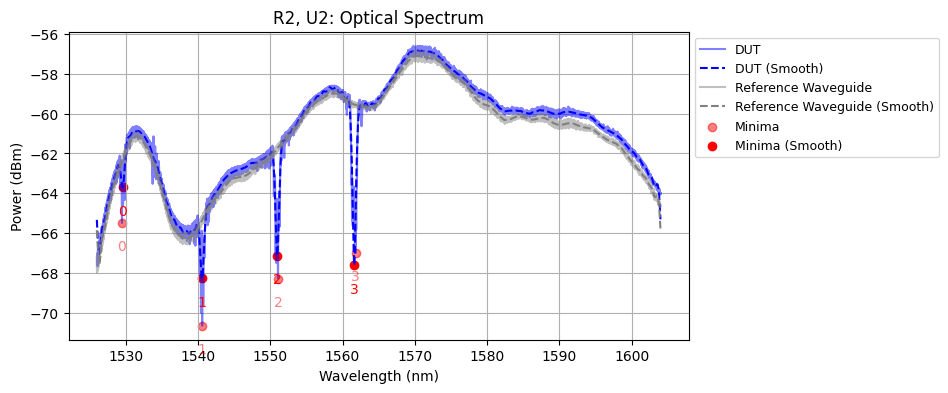

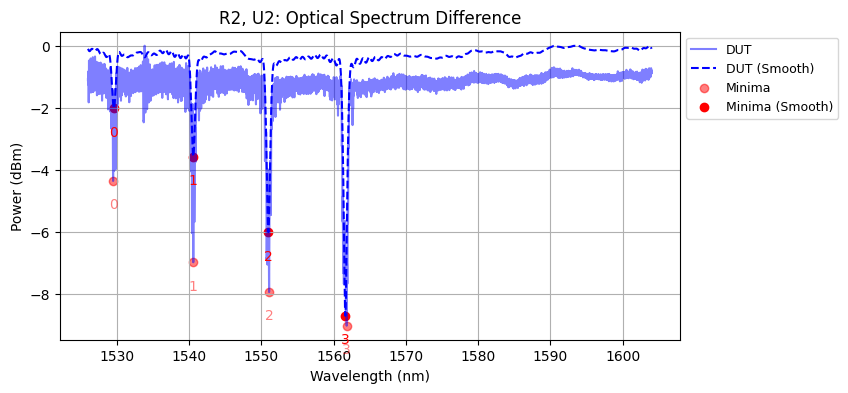

Minimums found in R2, U2 at wavelengths: [1529.476 1540.576 1551.064 1561.8  ] nm


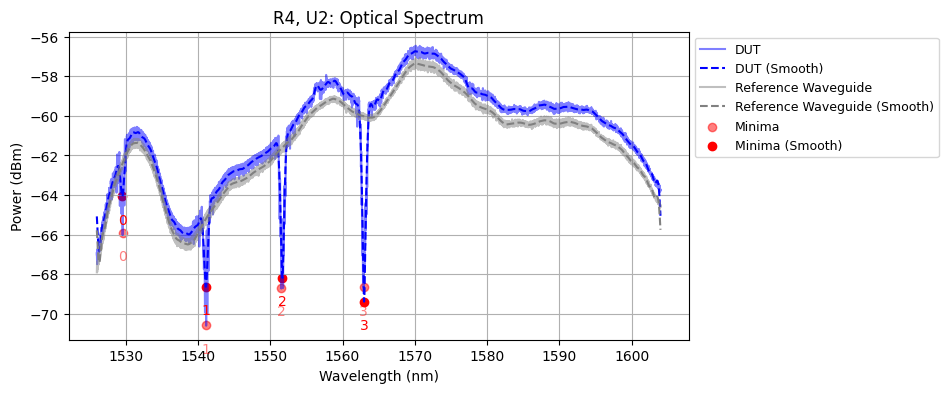

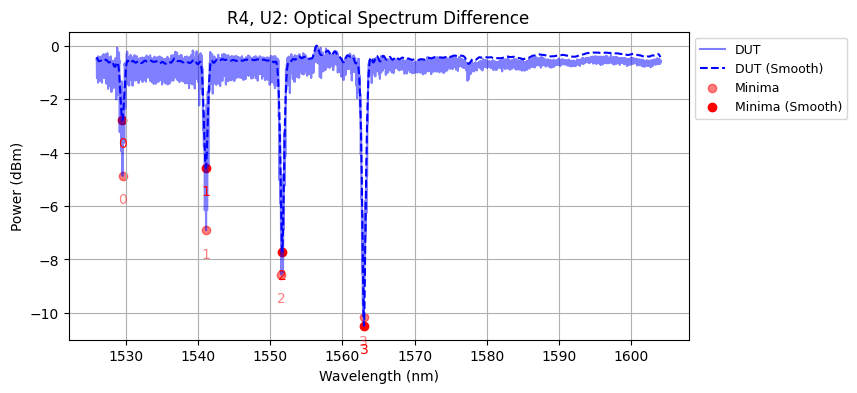

Minimums found in R4, U2 at wavelengths: [1529.576 1541.132 1551.536 1562.92 ] nm


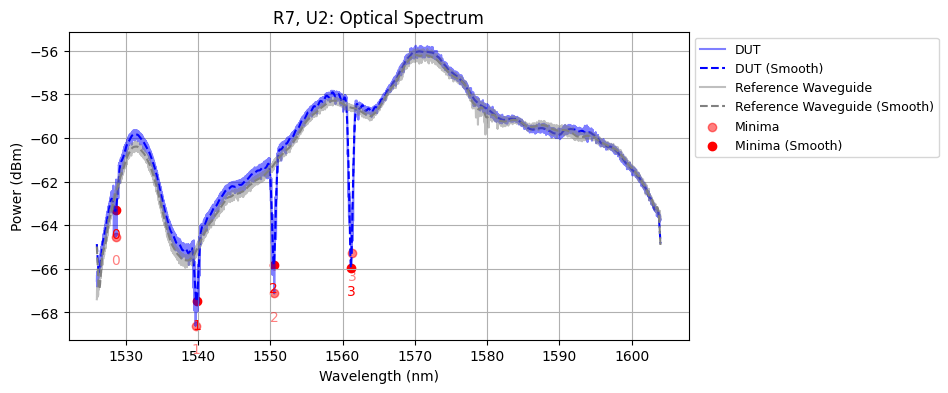

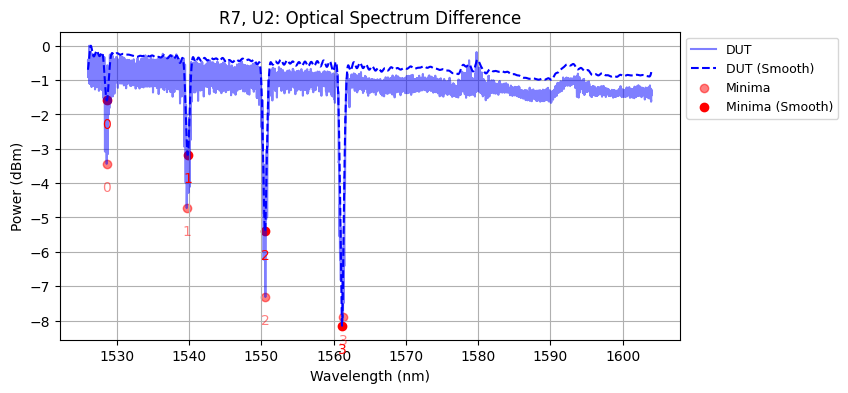

Minimums found in R7, U2 at wavelengths: [1528.592 1539.664 1550.552 1561.284] nm


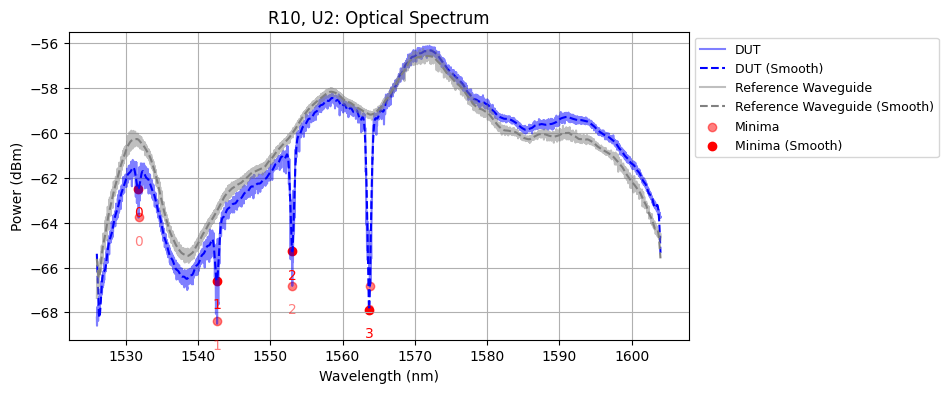

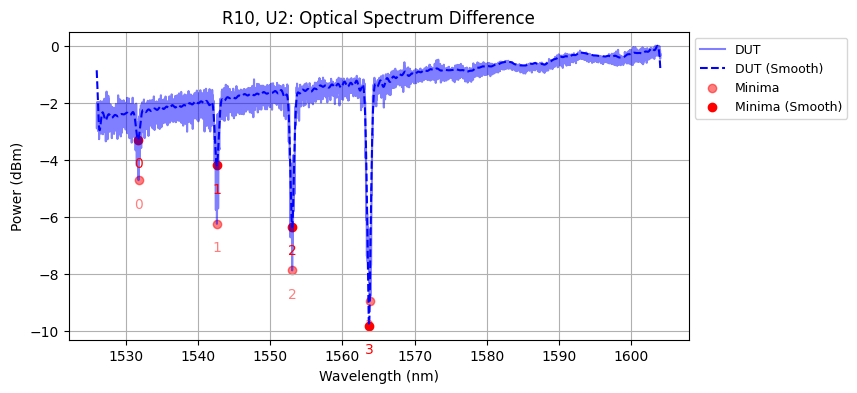

Minimums found in R10, U2 at wavelengths: [1531.784 1542.632 1553.044 1563.776] nm


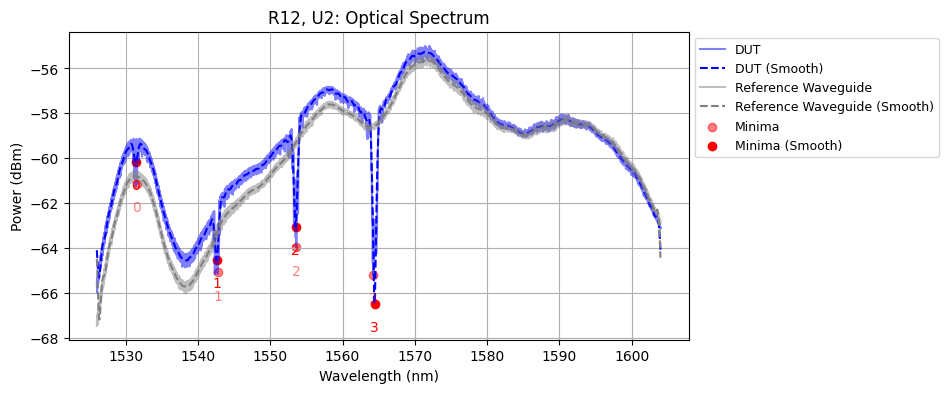

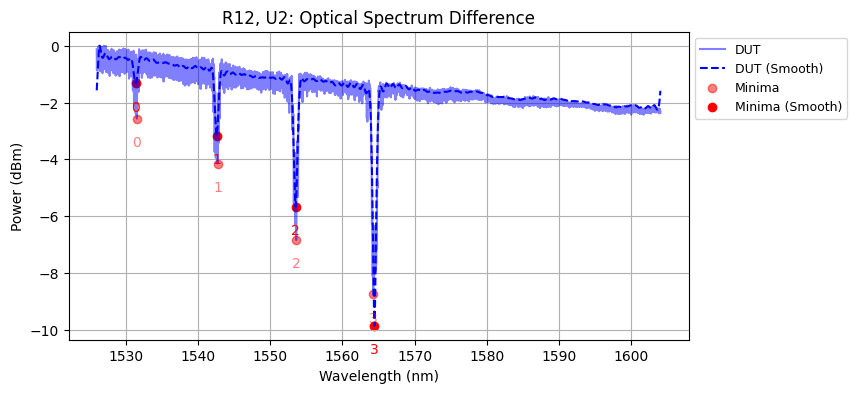

Minimums found in R12, U2 at wavelengths: [1531.548 1542.724 1553.608 1564.268] nm


In [12]:
# Processing parameters
tc = 0.01         # Cutoff time for Fourier filtering (s)
threshold = 2       # For minima detection (dB)
threshold_s = 0.8   
separation = 10      # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

# Smooth spectra
power_u2_r2_s = smooth_signal(wavelength_u2_r2, power_u2_r2, tc=tc, plot=False)
power_u2_r4_s = smooth_signal(wavelength_u2_r4, power_u2_r4, tc=tc, plot=False)
power_u2_r7_s = smooth_signal(wavelength_u2_r7, power_u2_r7, tc=tc, plot=False)
power_u2_r10_s = smooth_signal(wavelength_u2_r10, power_u2_r10, tc=tc, plot=False)
power_u2_r12_s = smooth_signal(wavelength_u2_r12, power_u2_r12, tc=tc, plot=False)

# Plot spectra and minima
wl_u2_r2, wl_u2_r2_s, power_u2_r2_min, power_u2_r2_min_s = plot_spectra_smooth(wavelength_u2_r2, power_u2_r2, power_u2_r2_s, power_wg_r2, power_wg_r2_s, threshold, threshold_s, separation, "R2, U2")
wl_u2_r4, wl_u2_r4_s, power_u2_r4_min, power_u2_r4_min_s = plot_spectra_smooth(wavelength_u2_r4, power_u2_r4, power_u2_r4_s, power_wg_r4, power_wg_r4_s, threshold, threshold_s, separation, "R4, U2")
wl_u2_r7, wl_u2_r7_s, power_u2_r7_min, power_u2_r7_min_s = plot_spectra_smooth(wavelength_u2_r7, power_u2_r7, power_u2_r7_s, power_wg_r7, power_wg_r7_s, threshold, threshold_s, separation, "R7, U2")
wl_u2_r10, wl_u2_r10_s, power_u2_r10_min, power_u2_r10_min_s = plot_spectra_smooth(wavelength_u2_r10, power_u2_r10, power_u2_r10_s, power_wg_r10, power_wg_r10_s, threshold, threshold_s, separation, "R10, U2")
wl_u2_r12, wl_u2_r12_s, power_u2_r12_min, power_u2_r12_min_s = plot_spectra_smooth(wavelength_u2_r12, power_u2_r12, power_u2_r12_s, power_wg_r12, power_wg_r12_s, threshold, threshold_s, separation, "R12, U2")


### Reflectivity & Grating Strength

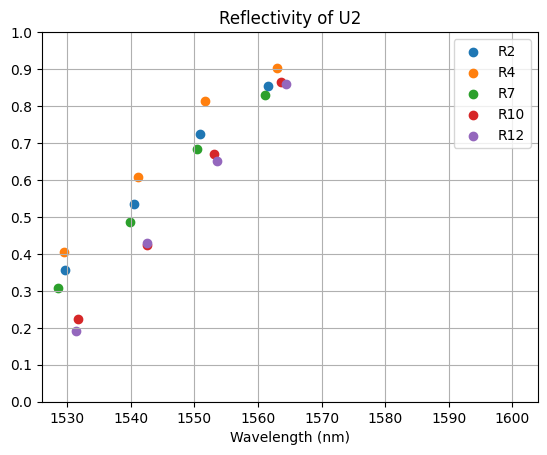

In [13]:
R_u2_r2_s, BW_u2_r2_s = reflectivity(wavelength_u2_r2, power_u2_r2_s, power_wg_r2_s, threshold_s, separation, window_size)
R_u2_r4_s, BW_u2_r4_s = reflectivity(wavelength_u2_r4, power_u2_r4_s, power_wg_r4_s, threshold_s, separation, window_size)
R_u2_r7_s, BW_u2_r7_s = reflectivity(wavelength_u2_r7, power_u2_r7_s, power_wg_r7_s, threshold_s, separation, window_size)
R_u2_r10_s, BW_u2_r10_s = reflectivity(wavelength_u2_r10, power_u2_r10_s, power_wg_r10_s, threshold_s, separation, window_size)
R_u2_r12_s, BW_u2_r12_s = reflectivity(wavelength_u2_r12, power_u2_r12_s, power_wg_r12_s, threshold_s, separation, window_size)

plt.scatter(wl_u2_r2_s, R_u2_r2_s, label='R2')
plt.scatter(wl_u2_r4_s, R_u2_r4_s, label='R4')
plt.scatter(wl_u2_r7_s, R_u2_r7_s, label='R7')
plt.scatter(wl_u2_r10_s, R_u2_r10_s, label='R10')
plt.scatter(wl_u2_r12_s, R_u2_r12_s, label='R12')

plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U2")
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

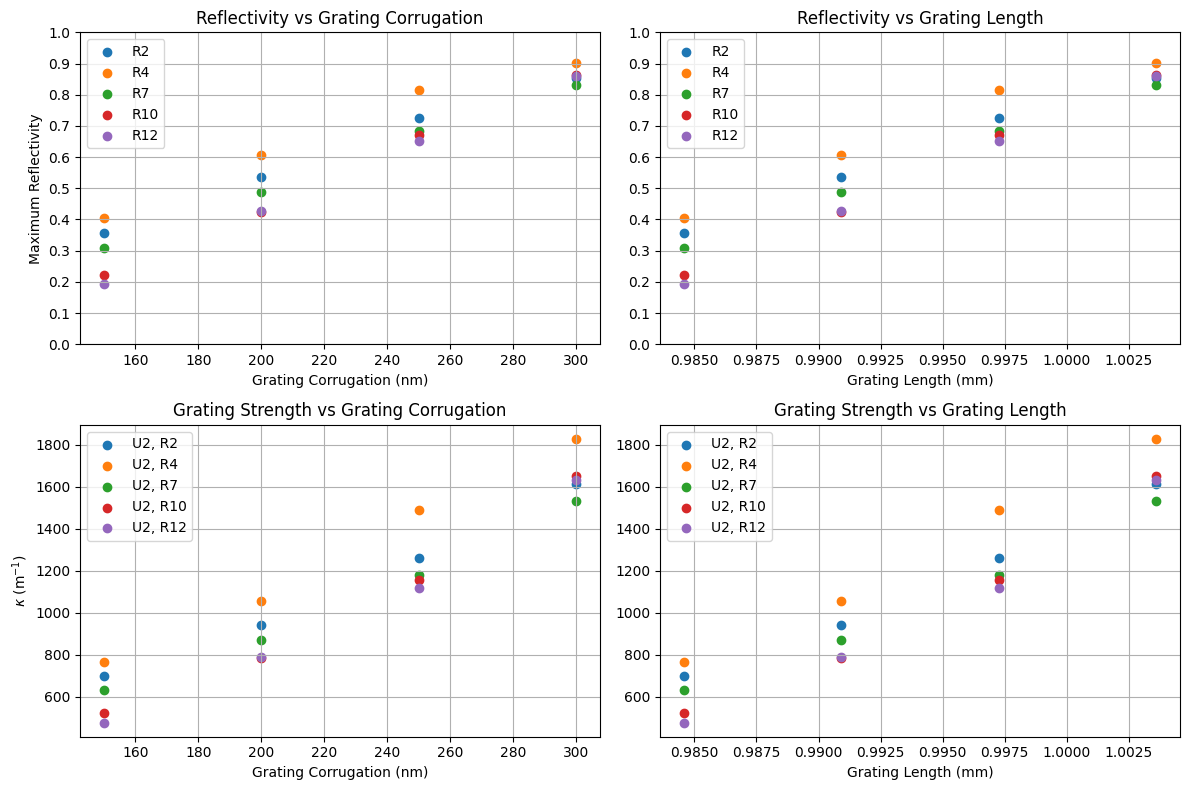

In [14]:
k_u2_r2_s, L_u2_r2_s, dW_u2_r2_s = grating_strength(wl_u2, wl_u2_r2_s, R_u2_r2_s, dW_u2, N_u2, n_eff)
k_u2_r4_s, L_u2_r4_s, dW_u2_r4_s = grating_strength(wl_u2, wl_u2_r4_s, R_u2_r4_s, dW_u2, N_u2, n_eff)
k_u2_r7_s, L_u2_r7_s, dW_u2_r7_s = grating_strength(wl_u2, wl_u2_r7_s, R_u2_r7_s, dW_u2, N_u2, n_eff)
k_u2_r10_s, L_u2_r10_s, dW_u2_r10_s = grating_strength(wl_u2, wl_u2_r10_s, R_u2_r10_s, dW_u2, N_u2, n_eff)
k_u2_r12_s, L_u2_r12_s, dW_u2_r12_s = grating_strength(wl_u2, wl_u2_r12_s, R_u2_r12_s, dW_u2, N_u2, n_eff)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].scatter(dW_u2_r2_s, R_u2_r2_s, label = 'R2')
axs[0, 0].scatter(dW_u2_r4_s, R_u2_r4_s, label = 'R4')
axs[0, 0].scatter(dW_u2_r7_s, R_u2_r7_s, label = 'R7')
axs[0, 0].scatter(dW_u2_r10_s, R_u2_r10_s, label = 'R10')
axs[0, 0].scatter(dW_u2_r12_s, R_u2_r12_s, label = 'R12')

axs[0, 0].set_xlabel("Grating Corrugation (nm)")
axs[0, 0].set_ylabel("Maximum Reflectivity")
axs[0, 0].set_title("Reflectivity vs Grating Corrugation")
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 0].grid()
axs[0, 0].legend()   

axs[0, 1].scatter(L_u2_r2_s*1e3, R_u2_r2_s, label = 'R2')
axs[0, 1].scatter(L_u2_r4_s*1e3, R_u2_r4_s, label = 'R4')
axs[0, 1].scatter(L_u2_r7_s*1e3, R_u2_r7_s, label = 'R7')
axs[0, 1].scatter(L_u2_r10_s*1e3, R_u2_r10_s, label = 'R10')
axs[0, 1].scatter(L_u2_r12_s*1e3, R_u2_r12_s, label = 'R12')
axs[0, 1].set_title("Reflectivity vs Grating Length")

axs[0, 1].set_xlabel("Grating Length (mm)")
axs[0, 1].set_ylim(0, 1)
axs[0, 1].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 1].grid()
axs[0, 1].legend() 


axs[1, 0].scatter(dW_u2_r2_s, k_u2_r2_s, label = 'U2, R2')
axs[1, 0].scatter(dW_u2_r4_s, k_u2_r4_s, label = 'U2, R4')
axs[1, 0].scatter(dW_u2_r7_s, k_u2_r7_s, label = 'U2, R7')
axs[1, 0].scatter(dW_u2_r10_s, k_u2_r10_s, label = 'U2, R10')
axs[1, 0].scatter(dW_u2_r12_s, k_u2_r12_s, label = 'U2, R12')
axs[1, 0].set_xlabel("Grating Corrugation (nm)")
axs[1, 0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[1, 0].set_title(r"Grating Strength vs Grating Corrugation")
axs[1, 0].grid()
axs[1, 0].legend()   

axs[1, 1].scatter(L_u2_r2_s*1e3, k_u2_r2_s, label = 'U2, R2')
axs[1, 1].scatter(L_u2_r4_s*1e3, k_u2_r4_s, label = 'U2, R4')
axs[1, 1].scatter(L_u2_r7_s*1e3, k_u2_r7_s, label = 'U2, R7')
axs[1, 1].scatter(L_u2_r10_s*1e3, k_u2_r10_s, label = 'U2, R10')
axs[1, 1].scatter(L_u2_r12_s*1e3, k_u2_r12_s, label = 'U2, R12')
axs[1, 1].set_xlabel("Grating Length (mm)")
axs[1, 1].set_title(r"Grating Strength vs Grating Length")
axs[1, 1].grid()
axs[1, 1].legend()   

plt.tight_layout()
plt.show()

### Refractive Index

/tmp/ipykernel_6539/809131327.py:52: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/arjoa/UPVfab/test_osa/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65298 (\N{FULLWIDTH DIGIT TWO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


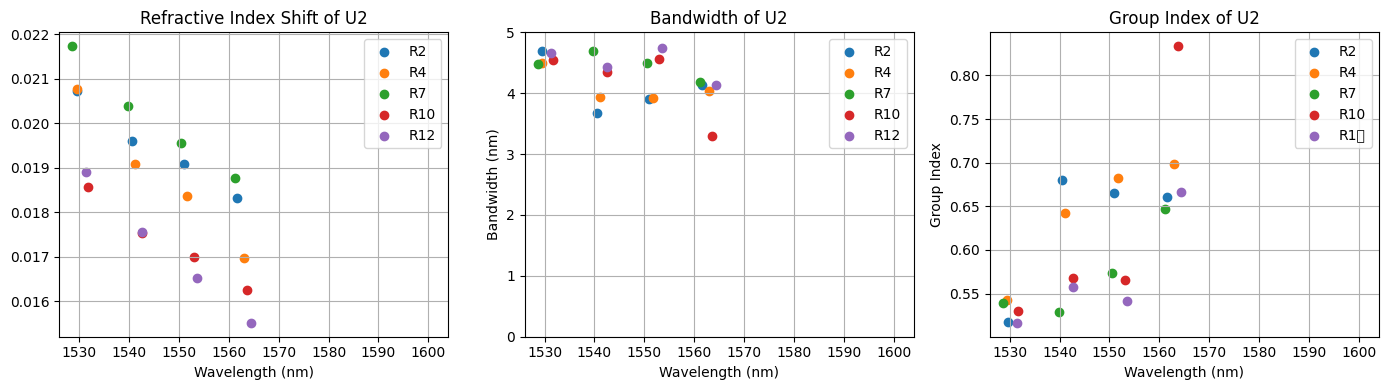

In [15]:
dwl_u2_r2_s, dn_u2_r2_s = shift_analysis(wl_u2, wl_u2_r2_s, n_eff)
dwl_u2_r4_s, dn_u2_r4_s = shift_analysis(wl_u2, wl_u2_r4_s, n_eff)
dwl_u2_r7_s, dn_u2_r7_s = shift_analysis(wl_u2, wl_u2_r7_s, n_eff)
dwl_u2_r10_s, dn_u2_r10_s = shift_analysis(wl_u2, wl_u2_r10_s, n_eff)
dwl_u2_r12_s, dn_u2_r12_s = shift_analysis(wl_u2, wl_u2_r12_s, n_eff)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].scatter(wl_u2_r2_s, dn_u2_r2_s, label='R2')
axs[0].scatter(wl_u2_r4_s, dn_u2_r4_s, label='R4')
axs[0].scatter(wl_u2_r7_s, dn_u2_r7_s, label='R7')
axs[0].scatter(wl_u2_r10_s, dn_u2_r10_s, label='R10')
axs[0].scatter(wl_u2_r12_s, dn_u2_r12_s, label='R12')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_title("Refractive Index Shift of U2")
axs[0].set_xlim(wl_0, wl_1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(wl_u2_r2_s, BW_u2_r2_s, label='R2')
axs[1].scatter(wl_u2_r4_s, BW_u2_r4_s, label='R4')
axs[1].scatter(wl_u2_r7_s, BW_u2_r7_s, label='R7')
axs[1].scatter(wl_u2_r10_s, BW_u2_r10_s, label='R10')
axs[1].scatter(wl_u2_r12_s, BW_u2_r12_s, label='R12')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("Bandwidth (nm)")
axs[1].set_title("Bandwidth of U2")
axs[1].set_xlim(wl_0, wl_1)
axs[1].set_ylim(0, 5)
axs[1].grid()
axs[1].legend()

ng_u2_r2 = group_index(wl_u2_r2_s, BW_u2_r2_s, k_u2_r2_s, L_u2_r2_s)
ng_u2_r4 = group_index(wl_u2_r4_s, BW_u2_r4_s, k_u2_r4_s, L_u2_r4_s)
ng_u2_r7 = group_index(wl_u2_r7_s, BW_u2_r7_s, k_u2_r7_s, L_u2_r7_s)
ng_u2_r10 = group_index(wl_u2_r10_s, BW_u2_r10_s, k_u2_r10_s, L_u2_r10_s)
ng_u2_r12 = group_index(wl_u2_r12_s, BW_u2_r12_s, k_u2_r12_s, L_u2_r12_s)    

axs[2].scatter(wl_u2_r2_s, ng_u2_r2, label='R2')
axs[2].scatter(wl_u2_r4_s, ng_u2_r4, label='R4')
axs[2].scatter(wl_u2_r7_s, ng_u2_r7, label='R7')
axs[2].scatter(wl_u2_r10_s, ng_u2_r10, label='R10')
axs[2].scatter(wl_u2_r12_s, ng_u2_r12, label='R1２')

axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('Group Index')
axs[2].set_title('Group Index of U2')
axs[2].legend()
axs[2].grid()
axs[2].set_xlim(wl_0, wl_1)

plt.tight_layout()
plt.show()

## U3

### Optical Spectrum

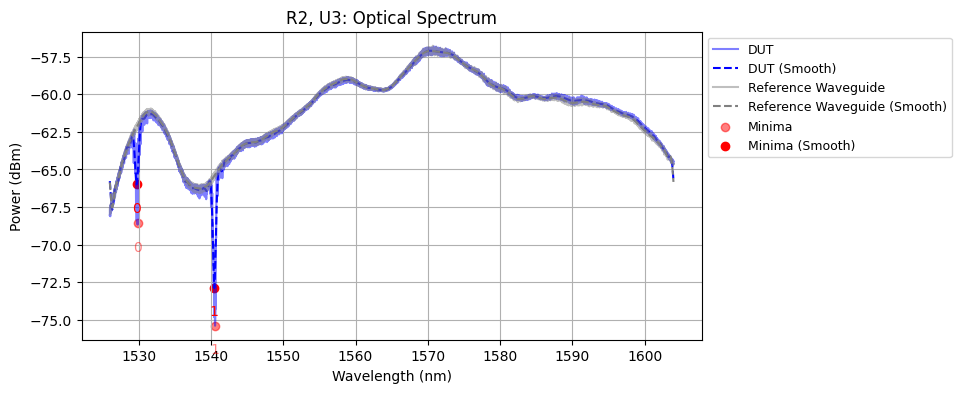

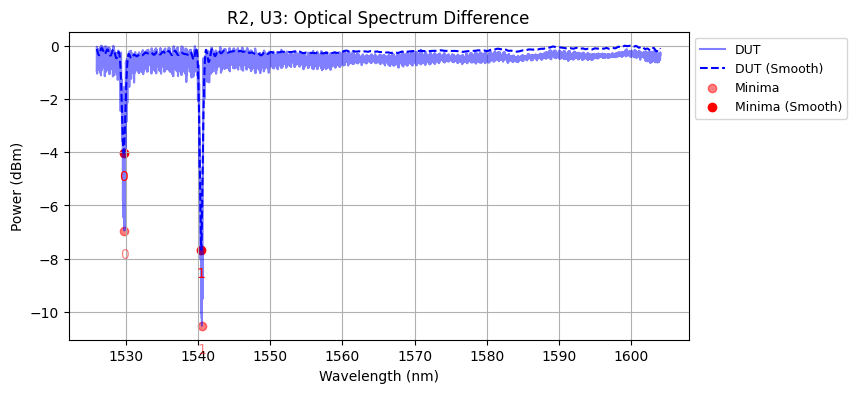

Minimums found in R2, U3 at wavelengths: [1529.844 1540.56 ] nm


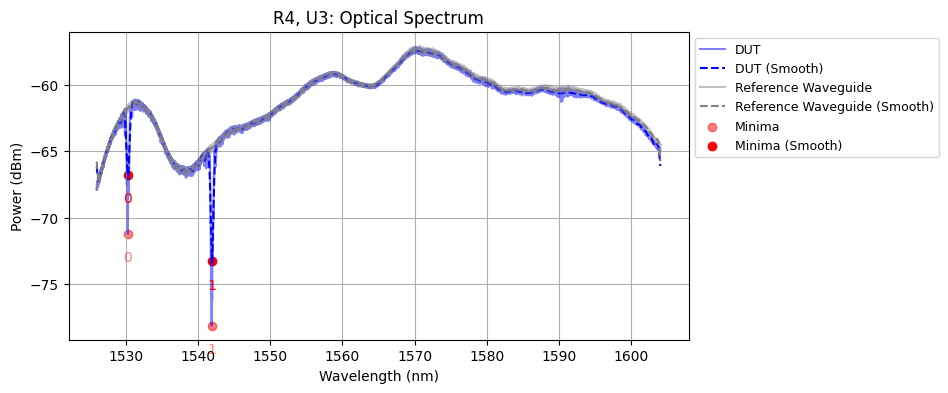

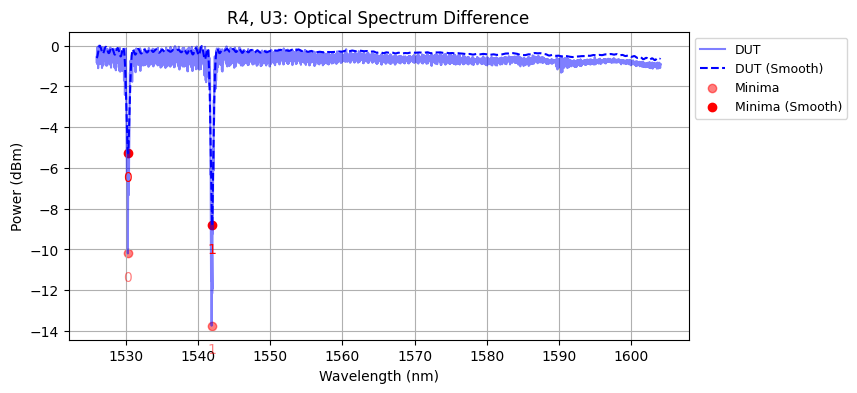

Minimums found in R4, U3 at wavelengths: [1530.304 1541.9  ] nm


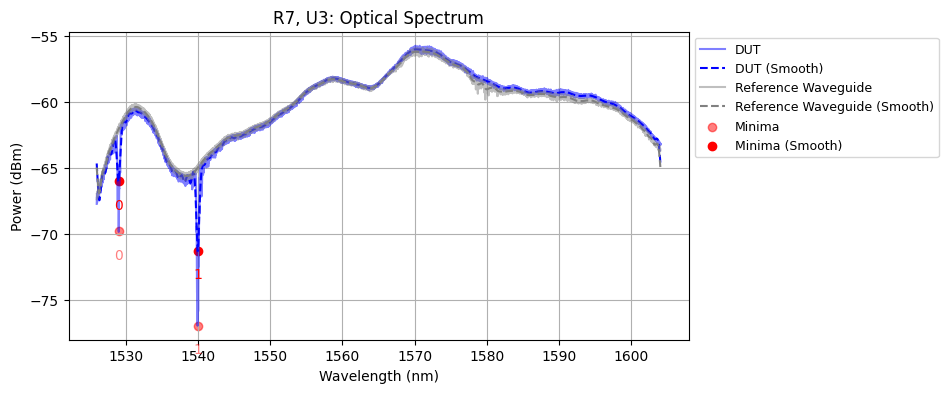

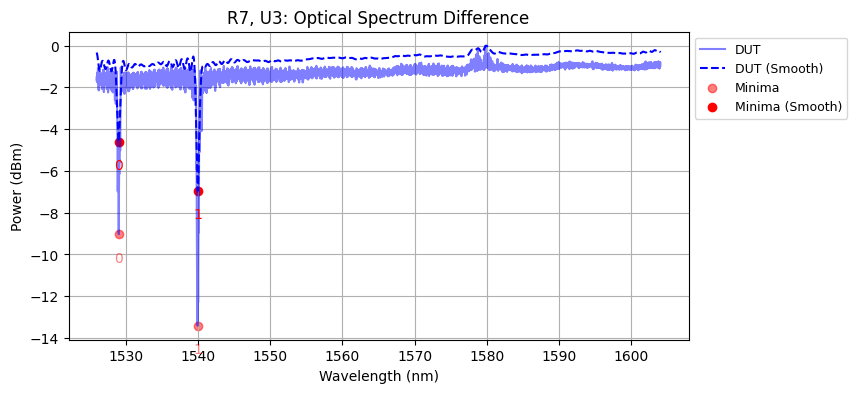

Minimums found in R7, U3 at wavelengths: [1529.048 1539.952] nm


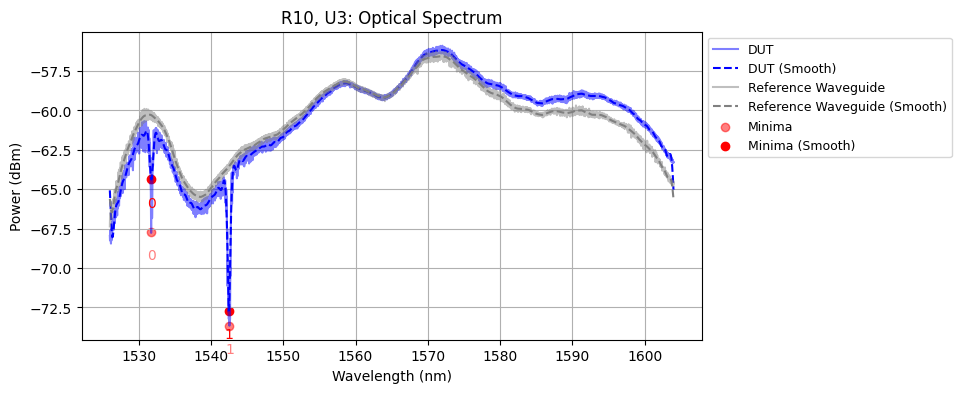

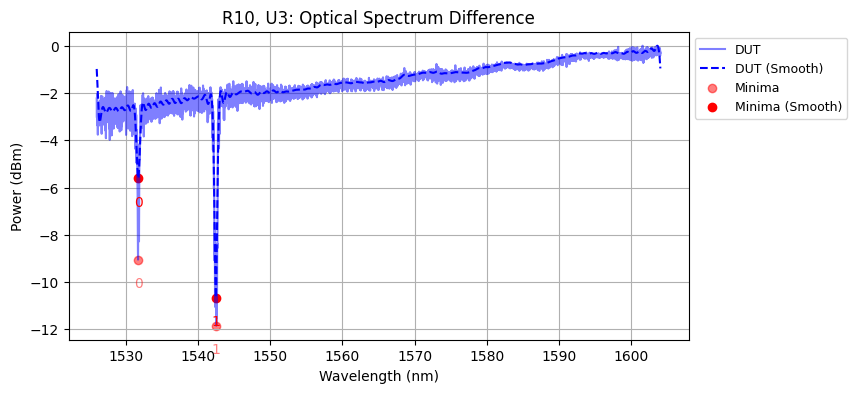

Minimums found in R10, U3 at wavelengths: [1531.72  1542.548] nm


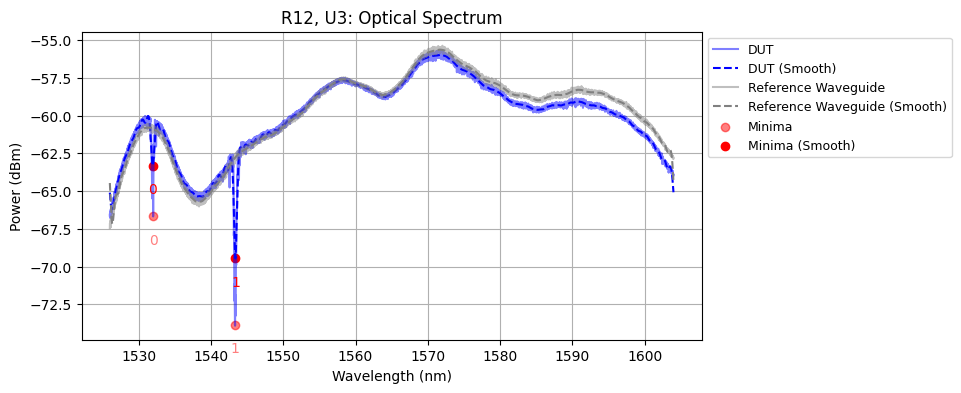

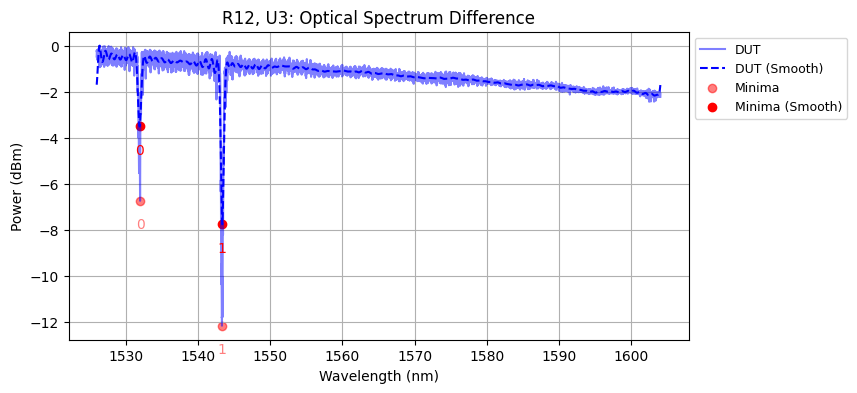

Minimums found in R12, U3 at wavelengths: [1532.    1543.332] nm


In [16]:
# Processing parameters
tc = 0.01         # Cutoff time for Fourier filtering (s)
threshold = 2       # For minima detection (dB)
threshold_s = 0.8   
separation = 10      # Minimum separation between minima (nm)
window_size = 5     # For zooming in on minima (nm)

# Smooth spectra
power_u3_r2_s = smooth_signal(wavelength_u3_r2, power_u3_r2, tc=tc, plot=False)
power_u3_r4_s = smooth_signal(wavelength_u3_r4, power_u3_r4, tc=tc, plot=False)
power_u3_r7_s = smooth_signal(wavelength_u3_r7, power_u3_r7, tc=tc, plot=False)
power_u3_r10_s = smooth_signal(wavelength_u3_r10, power_u3_r10, tc=tc, plot=False)
power_u3_r12_s = smooth_signal(wavelength_u3_r12, power_u3_r12, tc=tc, plot=False)

# Plot spectra and minima
wl_u3_r2, wl_u3_r2_s, power_u3_r2_min, power_u3_r2_min_s = plot_spectra_smooth(wavelength_u3_r2, power_u3_r2, power_u3_r2_s, power_wg_r2, power_wg_r2_s, threshold, threshold_s, separation, "R2, U3")
wl_u3_r4, wl_u3_r4_s, power_u3_r4_min, power_u3_r4_min_s = plot_spectra_smooth(wavelength_u3_r4, power_u3_r4, power_u3_r4_s, power_wg_r4, power_wg_r4_s, threshold, threshold_s, separation, "R4, U3")
wl_u3_r7, wl_u3_r7_s, power_u3_r7_min, power_u3_r7_min_s = plot_spectra_smooth(wavelength_u3_r7, power_u3_r7, power_u3_r7_s, power_wg_r7, power_wg_r7_s, threshold, threshold_s, separation, "R7, U3")
wl_u3_r10, wl_u3_r10_s, power_u3_r10_min, power_u3_r10_min_s = plot_spectra_smooth(wavelength_u3_r10, power_u3_r10, power_u3_r10_s, power_wg_r10, power_wg_r10_s, threshold, threshold_s, separation, "R10, U3")
wl_u3_r12, wl_u3_r12_s, power_u3_r12_min, power_u3_r12_min_s = plot_spectra_smooth(wavelength_u3_r12, power_u3_r12, power_u3_r12_s, power_wg_r12, power_wg_r12_s, threshold, threshold_s, separation, "R12, U3")


### Reflectivity & Grating Strength

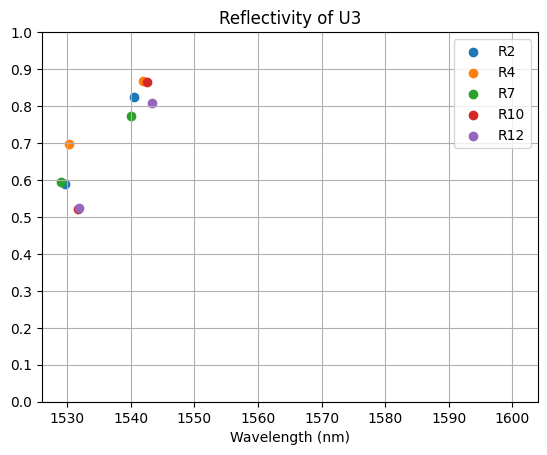

In [17]:
R_u3_r2_s, BW_u3_r2_s = reflectivity(wavelength_u3_r2, power_u3_r2_s, power_wg_r2_s, threshold_s, separation, window_size)
R_u3_r4_s, BW_u3_r4_s = reflectivity(wavelength_u3_r4, power_u3_r4_s, power_wg_r4_s, threshold_s, separation, window_size)
R_u3_r7_s, BW_u3_r7_s = reflectivity(wavelength_u3_r7, power_u3_r7_s, power_wg_r7_s, threshold_s, separation, window_size)
R_u3_r10_s, BW_u3_r10_s = reflectivity(wavelength_u3_r10, power_u3_r10_s, power_wg_r10_s, threshold_s, separation, window_size)
R_u3_r12_s, BW_u3_r12_s = reflectivity(wavelength_u3_r12, power_u3_r12_s, power_wg_r12_s, threshold_s, separation, window_size)

plt.scatter(wl_u3_r2_s, R_u3_r2_s, label='R2')
plt.scatter(wl_u3_r4_s, R_u3_r4_s, label='R4')
plt.scatter(wl_u3_r7_s, R_u3_r7_s, label='R7')
plt.scatter(wl_u3_r10_s, R_u3_r10_s, label='R10')
plt.scatter(wl_u3_r12_s, R_u3_r12_s, label='R12')

plt.xlabel("Wavelength (nm)")
plt.title("Reflectivity of U3")
plt.ylim(0, 1)
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.xlim(wl_0, wl_1)
plt.grid()
plt.legend()
plt.show()

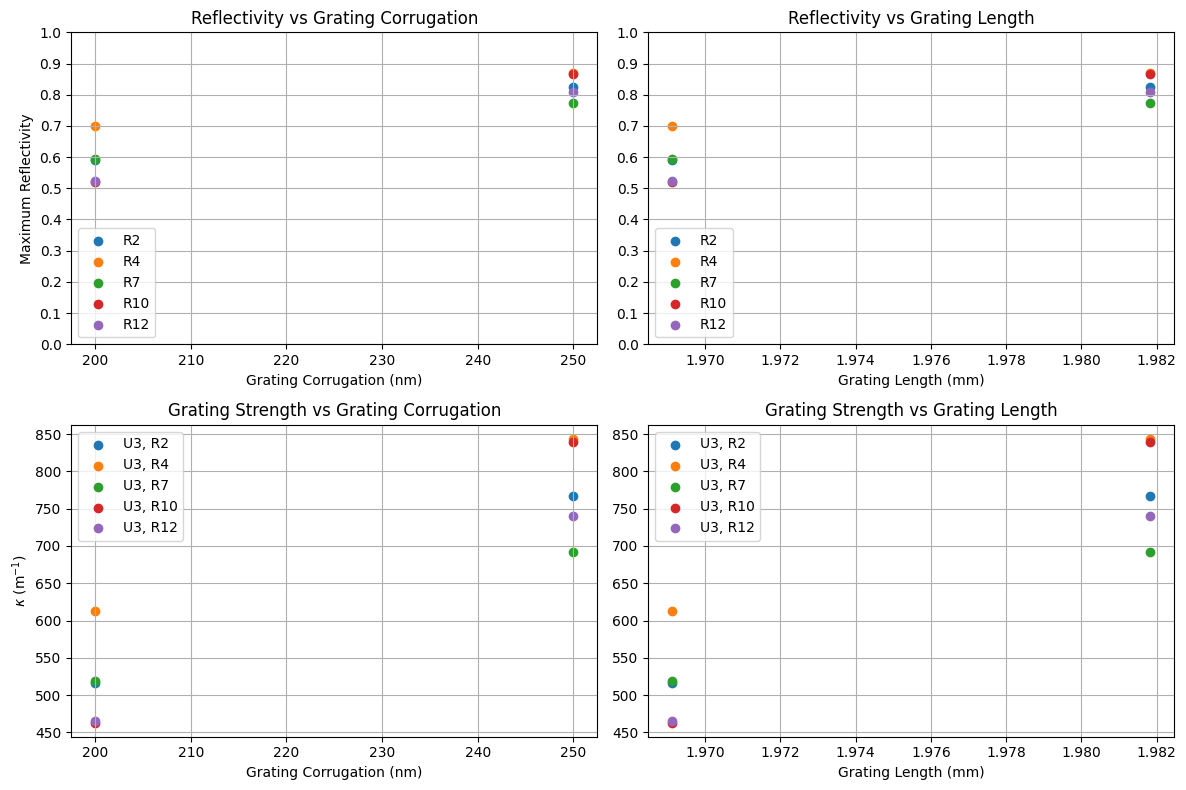

In [18]:
k_u3_r2_s, L_u3_r2_s, dW_u3_r2_s = grating_strength(wl_u3, wl_u3_r2_s, R_u3_r2_s, dW_u3, N_u3, n_eff)
k_u3_r4_s, L_u3_r4_s, dW_u3_r4_s = grating_strength(wl_u3, wl_u3_r4_s, R_u3_r4_s, dW_u3, N_u3, n_eff)
k_u3_r7_s, L_u3_r7_s, dW_u3_r7_s = grating_strength(wl_u3, wl_u3_r7_s, R_u3_r7_s, dW_u3, N_u3, n_eff)
k_u3_r10_s, L_u3_r10_s, dW_u3_r10_s = grating_strength(wl_u3, wl_u3_r10_s, R_u3_r10_s, dW_u3, N_u3, n_eff)
k_u3_r12_s, L_u3_r12_s, dW_u3_r12_s = grating_strength(wl_u3, wl_u3_r12_s, R_u3_r12_s, dW_u3, N_u3, n_eff)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].scatter(dW_u3_r2_s, R_u3_r2_s, label = 'R2')
axs[0, 0].scatter(dW_u3_r4_s, R_u3_r4_s, label = 'R4')
axs[0, 0].scatter(dW_u3_r7_s, R_u3_r7_s, label = 'R7')
axs[0, 0].scatter(dW_u3_r10_s, R_u3_r10_s, label = 'R10')
axs[0, 0].scatter(dW_u3_r12_s, R_u3_r12_s, label = 'R12')

axs[0, 0].set_xlabel("Grating Corrugation (nm)")
axs[0, 0].set_ylabel("Maximum Reflectivity")
axs[0, 0].set_title("Reflectivity vs Grating Corrugation")
axs[0, 0].set_ylim(0, 1)
axs[0, 0].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 0].grid()
axs[0, 0].legend()   

axs[0, 1].scatter(L_u3_r2_s*1e3, R_u3_r2_s, label = 'R2')
axs[0, 1].scatter(L_u3_r4_s*1e3, R_u3_r4_s, label = 'R4')
axs[0, 1].scatter(L_u3_r7_s*1e3, R_u3_r7_s, label = 'R7')
axs[0, 1].scatter(L_u3_r10_s*1e3, R_u3_r10_s, label = 'R10')
axs[0, 1].scatter(L_u3_r12_s*1e3, R_u3_r12_s, label = 'R12')
axs[0, 1].set_title("Reflectivity vs Grating Length")

axs[0, 1].set_xlabel("Grating Length (mm)")
axs[0, 1].set_ylim(0, 1)
axs[0, 1].set_yticks(np.arange(0.0, 1.1, 0.1))
axs[0, 1].grid()
axs[0, 1].legend() 


axs[1, 0].scatter(dW_u3_r2_s, k_u3_r2_s, label = 'U3, R2')
axs[1, 0].scatter(dW_u3_r4_s, k_u3_r4_s, label = 'U3, R4')
axs[1, 0].scatter(dW_u3_r7_s, k_u3_r7_s, label = 'U3, R7')
axs[1, 0].scatter(dW_u3_r10_s, k_u3_r10_s, label = 'U3, R10')
axs[1, 0].scatter(dW_u3_r12_s, k_u3_r12_s, label = 'U3, R12')
axs[1, 0].set_xlabel("Grating Corrugation (nm)")
axs[1, 0].set_ylabel(r"$\kappa$ (m$^{-1}$)")
axs[1, 0].set_title(r"Grating Strength vs Grating Corrugation")
axs[1, 0].grid()
axs[1, 0].legend()   

axs[1, 1].scatter(L_u3_r2_s*1e3, k_u3_r2_s, label = 'U3, R2')
axs[1, 1].scatter(L_u3_r4_s*1e3, k_u3_r4_s, label = 'U3, R4')
axs[1, 1].scatter(L_u3_r7_s*1e3, k_u3_r7_s, label = 'U3, R7')
axs[1, 1].scatter(L_u3_r10_s*1e3, k_u3_r10_s, label = 'U3, R10')
axs[1, 1].scatter(L_u3_r12_s*1e3, k_u3_r12_s, label = 'U3, R12')
axs[1, 1].set_xlabel("Grating Length (mm)")
axs[1, 1].set_title(r"Grating Strength vs Grating Length")
axs[1, 1].grid()
axs[1, 1].legend()   

plt.tight_layout()
plt.show()

### Refractive Index

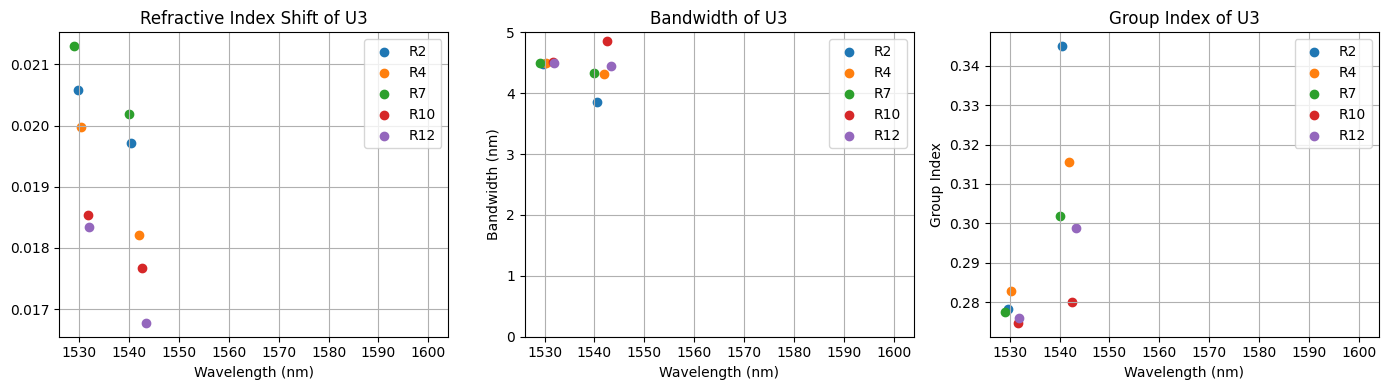

In [19]:
dwl_u3_r2_s, dn_u3_r2_s = shift_analysis(wl_u3, wl_u3_r2_s, n_eff)
dwl_u3_r4_s, dn_u3_r4_s = shift_analysis(wl_u3, wl_u3_r4_s, n_eff)
dwl_u3_r7_s, dn_u3_r7_s = shift_analysis(wl_u3, wl_u3_r7_s, n_eff)
dwl_u3_r10_s, dn_u3_r10_s = shift_analysis(wl_u3, wl_u3_r10_s, n_eff)
dwl_u3_r12_s, dn_u3_r12_s = shift_analysis(wl_u3, wl_u3_r12_s, n_eff)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].scatter(wl_u3_r2_s, dn_u3_r2_s, label='R2')
axs[0].scatter(wl_u3_r4_s, dn_u3_r4_s, label='R4')
axs[0].scatter(wl_u3_r7_s, dn_u3_r7_s, label='R7')
axs[0].scatter(wl_u3_r10_s, dn_u3_r10_s, label='R10')
axs[0].scatter(wl_u3_r12_s, dn_u3_r12_s, label='R12')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_title("Refractive Index Shift of U3")
axs[0].set_xlim(wl_0, wl_1)
axs[0].grid()
axs[0].legend()   

axs[1].scatter(wl_u3_r2_s, BW_u3_r2_s, label='R2')
axs[1].scatter(wl_u3_r4_s, BW_u3_r4_s, label='R4')
axs[1].scatter(wl_u3_r7_s, BW_u3_r7_s, label='R7')
axs[1].scatter(wl_u3_r10_s, BW_u3_r10_s, label='R10')
axs[1].scatter(wl_u3_r12_s, BW_u3_r12_s, label='R12')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("Bandwidth (nm)")
axs[1].set_title("Bandwidth of U3")
axs[1].set_xlim(wl_0, wl_1)
axs[1].set_ylim(0, 5)
axs[1].grid()
axs[1].legend()

ng_u3_r2 = group_index(wl_u3_r2_s, BW_u3_r2_s, k_u3_r2_s, L_u3_r2_s)
ng_u3_r4 = group_index(wl_u3_r4_s, BW_u3_r4_s, k_u3_r4_s, L_u3_r4_s)
ng_u3_r7 = group_index(wl_u3_r7_s, BW_u3_r7_s, k_u3_r7_s, L_u3_r7_s)
ng_u3_r10 = group_index(wl_u3_r10_s, BW_u3_r10_s, k_u3_r10_s, L_u3_r10_s)
ng_u3_r12 = group_index(wl_u3_r12_s, BW_u3_r12_s, k_u3_r12_s, L_u3_r12_s)    

axs[2].scatter(wl_u3_r2_s, ng_u3_r2, label='R2')
axs[2].scatter(wl_u3_r4_s, ng_u3_r4, label='R4')
axs[2].scatter(wl_u3_r7_s, ng_u3_r7, label='R7')
axs[2].scatter(wl_u3_r10_s, ng_u3_r10, label='R10')
axs[2].scatter(wl_u3_r12_s, ng_u3_r12, label='R12')

axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('Group Index')
axs[2].set_title('Group Index of U3')
axs[2].legend()
axs[2].grid()
axs[2].set_xlim(wl_0, wl_1)

plt.tight_layout()
plt.show()

# Check

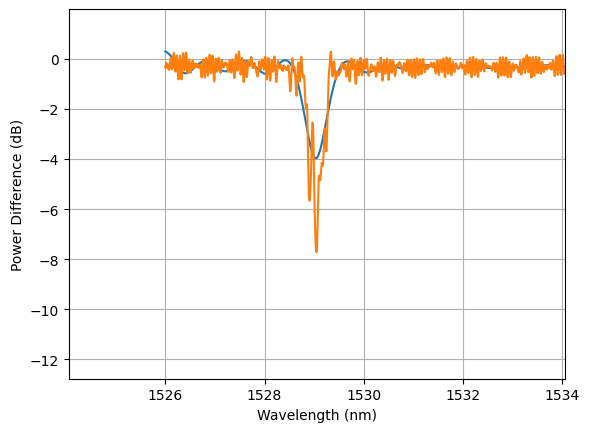

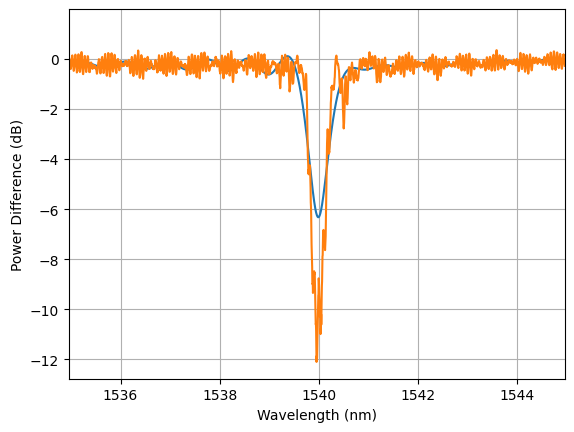

In [20]:
for i in range(len(wl_u3_r7)):
    plt.plot(wavelength_u3_r7, power_u3_r7_s - power_wg_r7_s)
    plt.plot(wavelength_u3_r7, power_u3_r7 - power_wg_r7)
    plt.xlim(wl_u3_r7[i]-window_size, wl_u3_r7[i]+window_size)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Power Difference (dB)")
    plt.grid()
    plt.show()

# Overall Grating Strength

In [21]:
def reflectivity_corrugation(w):
    buff_R = []
    buff_L = []
    mean_R = []
    mean_L = []

    if w < np.min([np.min(dW_u1_r2_s), np.min(dW_u2_r2_s), np.min(dW_u3_r2_s)]) or w > np.max([np.max(dW_u1_r2_s), np.max(dW_u2_r2_s), np.max(dW_u3_r2_s)]):
        print(f'No data')
        return None

    if w<min(dW_u1_r2_s) or w>max(dW_u1_r2_s):
        print(f'No data for U1 for grating corrugation of {w} nm')

    if w<min(dW_u2_r2_s) or w>max(dW_u2_r2_s):
        print(f'No data for U2 for grating corrugation of {w} nm')

    if w<min(dW_u3_r2_s) or w>max(dW_u3_r2_s):
        print(f'No data for U3 for grating corrugation of {w} nm')
    

    for i in range(len(dW_u1_r2_s)):
        if dW_u1_r2_s[i] == w:
            buff_R.append(R_u1_r2_s[i]); buff_R.append(R_u1_r4_s[i]); buff_R.append(R_u1_r7_s[i]); buff_R.append(R_u1_r10_s[i]); buff_R.append(R_u1_r12_s[i])
            mean_R.append(np.mean([R_u1_r2_s[i], R_u1_r4_s[i], R_u1_r7_s[i], R_u1_r10_s[i], R_u1_r12_s[i]]))

            buff_L.append(L_u1_r2_s[i]); buff_L.append(L_u1_r4_s[i]); buff_L.append(L_u1_r7_s[i]); buff_L.append(L_u1_r10_s[i]); buff_L.append(L_u1_r12_s[i])
            mean_L.append(np.mean([L_u1_r2_s[i], L_u1_r4_s[i], L_u1_r7_s[i], L_u1_r10_s[i], L_u1_r12_s[i]]))

    for i in range(len(dW_u2_r2_s)):
        if dW_u2_r2_s[i] == w:
            buff_R.append(R_u2_r2_s[i]); buff_R.append(R_u2_r4_s[i]); buff_R.append(R_u2_r7_s[i]); buff_R.append(R_u2_r10_s[i]); buff_R.append(R_u2_r12_s[i])
            mean_R.append(np.mean([R_u2_r2_s[i], R_u2_r4_s[i], R_u2_r7_s[i], R_u2_r10_s[i], R_u2_r12_s[i]]))

            buff_L.append(L_u2_r2_s[i]); buff_L.append(L_u2_r4_s[i]); buff_L.append(L_u2_r7_s[i]); buff_L.append(L_u2_r10_s[i]); buff_L.append(L_u2_r12_s[i])
            mean_L.append(np.mean([L_u2_r2_s[i], L_u2_r4_s[i], L_u2_r7_s[i], L_u2_r10_s[i], L_u2_r12_s[i]]))

    for i in range(len(dW_u3_r2_s)):
        if dW_u3_r2_s[i] == w:
            buff_R.append(R_u3_r2_s[i]); buff_R.append(R_u3_r4_s[i]); buff_R.append(R_u3_r7_s[i]); buff_R.append(R_u3_r10_s[i]); buff_R.append(R_u3_r12_s[i])
            mean_R.append(np.mean([R_u3_r2_s[i], R_u3_r4_s[i], R_u3_r7_s[i], R_u3_r10_s[i], R_u3_r12_s[i]]))

            buff_L.append(L_u3_r2_s[i]); buff_L.append(L_u3_r4_s[i]); buff_L.append(L_u3_r7_s[i]); buff_L.append(L_u3_r10_s[i]); buff_L.append(L_u3_r12_s[i])
            mean_L.append(np.mean([L_u3_r2_s[i], L_u3_r4_s[i], L_u3_r7_s[i], L_u3_r10_s[i], L_u3_r12_s[i]]))

    plt.scatter(np.array(buff_L)*1e3, np.array(buff_R), label='Data')
    plt.scatter(np.array(mean_L)*1e3, np.array(mean_R), label='Mean', color='r')
    plt.title(f'Maximum Reflectivity (Fourier) for Corrugation {w} nm')

    x = np.linspace(0, 1.5*np.max(buff_L), 100)
    popt, pcov = curve_fit(reflectivity_model, mean_L, mean_R)
    plt.plot(x*1e3, reflectivity_model(x, *popt), label=r'$tanh^2(\kappa L)$', color='orange')

    plt.annotate(rf'$\kappa$={popt[0]:.2f}, Cov.={pcov[0,0]:.2f}', xy=[0.95,0.05], xycoords = 'axes fraction', ha = 'right', va = 'bottom', fontsize=11)
    plt.legend()
    plt.xlabel('Grating Length (mm)')
    plt.ylabel('Reflectivity')
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.grid()
    plt.show()

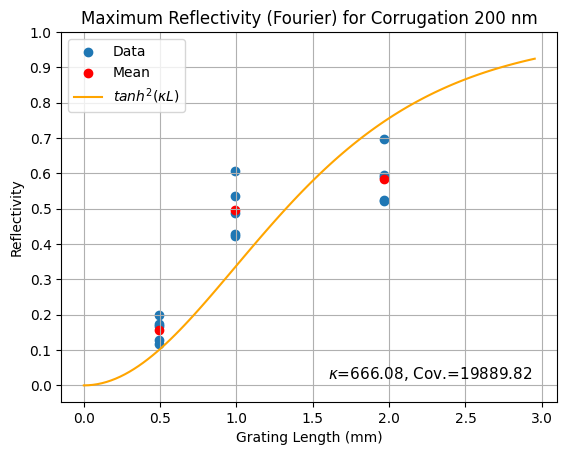

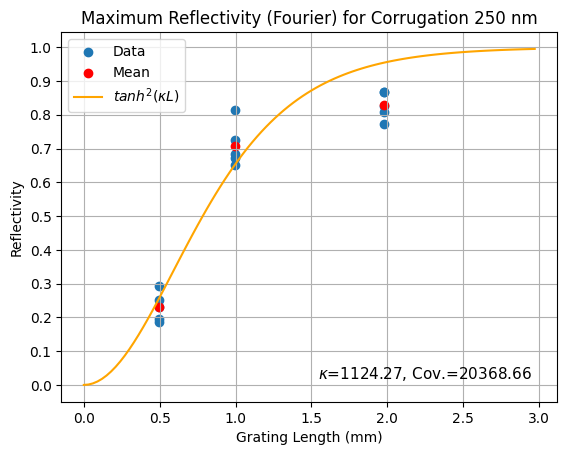

No data for U3 for grating corrugation of 300 nm


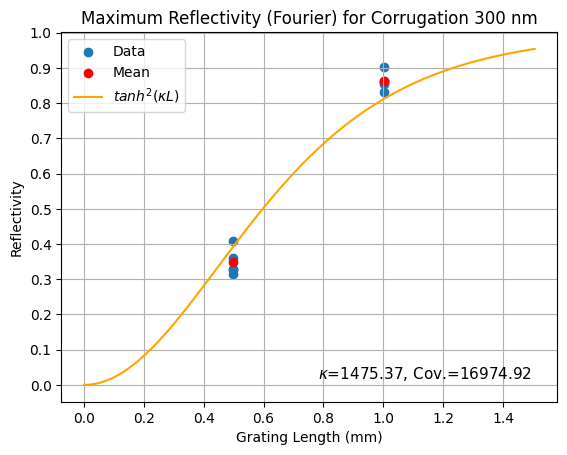

In [22]:
reflectivity_corrugation(200)
reflectivity_corrugation(250)
reflectivity_corrugation(300)